# Hotel booking demand



#### Data Source: https://www.kaggle.com/jessemostipak/hotel-booking-demand

#### Data Description: The data is a record of hotel booking demand. It contains 32 columns and 119390 rows. The columns include information about the booking, the hotel, the customer, and the stay. The data is in a CSV file format.



## Project Overview
In this project, we aim to build a machine learning model to predict whether a hotel booking will be canceled (`is_canceled`). This prediction is crucial for hotels to manage resources efficiently and optimize revenue. By accurately predicting cancellations, hotels can take proactive measures such as overbooking or offering promotions to minimize the impact of cancellations.

**Data Loading and Exploration:(EDA)**
    - Load the dataset and explore its structure and contents.
    - Understand the features and target variable.

**Data Preprocessing:**
    - Handle missing values and outliers.
    - Encode categorical variables.
    - Normalize or scale numerical features if necessary.

**Feature Selection:**
    - Select relevant features that contribute to the prediction of cancellations.
    - Split the data into features (`X`) and target variable (`y`).

**Data Splitting:**
    - Split the data into training and testing sets to evaluate the models performance.

**Model Building:**
    - Choose appropriate machine learning algorithms.
    - Train the model using the training data.
    - Tune hyperparameters to improve model performance.

**Model Evaluation:**
    - Evaluate the model using the testing data.
    - Use metrics such as accuracy, precision, recall, and F1-score to assess the models performance.

**Model Interpretation:**
    - Interpret the models predictions and understand the importance of different features.
    - Visualize the results and insights gained from the model.

**Deployment:**
    - Deploy the model for real-time prediction if required.
    - Create a user interface or API for easy access to the models predictions.

By following these steps, we aim to develop a robust model that can help hotels make data-driven decisions to optimize their operations and minimize the impact of booking cancellations.


### Target
The target variable in this dataset is the `is_canceled` column. This column indicates whether a hotel booking was canceled or not. It is a binary variable with the following possible values:

- `0`: The booking was not canceled.
- `1`: The booking was canceled.

In [1]:
# import os
# os.environ['MPLBACKEND'] = 'agg'  # or 'tkagg'
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import numpy as np


In [2]:

# Load the data
df = pd.read_csv('hotel_bookings.csv')

# Display the first few rows of the dataframe
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
#info about the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
# Divide the features into numerical and categorical types
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()


print("Numerical Features (Total: {}):".format(len(numerical_features)))
print(numerical_features)
print("\nCategorical Features (Total: {}):".format(len(categorical_features)))
print(categorical_features)

Numerical Features (Total: 20):
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Features (Total: 12):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


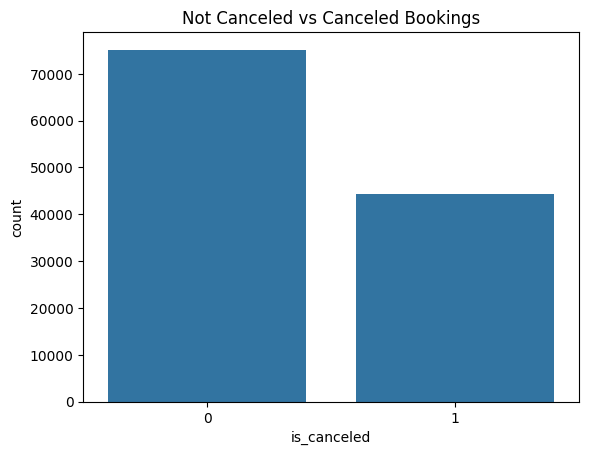

44224 Canceled (37.04%)
75166 Not Canceled (62.96%)


In [5]:
# Calculate the number of canceled and not canceled bookings
canceled = len(df[df["is_canceled"] == 1])
not_canceled = len(df[df["is_canceled"] == 0])
total = len(df)

# Plot the count of canceled vs not canceled bookings
sns.countplot(data=df, x="is_canceled")
plt.title("Not Canceled vs Canceled Bookings")
plt.show()

# Print the counts and percentages
print(f"{canceled} Canceled ({round(canceled / total * 100, 2)}%)")
print(f"{not_canceled} Not Canceled ({round(not_canceled / total * 100, 2)}%)")

In [6]:
# %pip install setuptools

In [7]:
# from ydata_profiling import ProfileReport

# # Assuming df is already defined
# design_report = ProfileReport(df)
# design_report.to_file(output_file='Hotel_Booking_Auto.html')

In [8]:

# import sweetviz as sv
# sweet_report = sv.analyze(df)
# sweet_report.show_html('Hotel_Booking_.html')

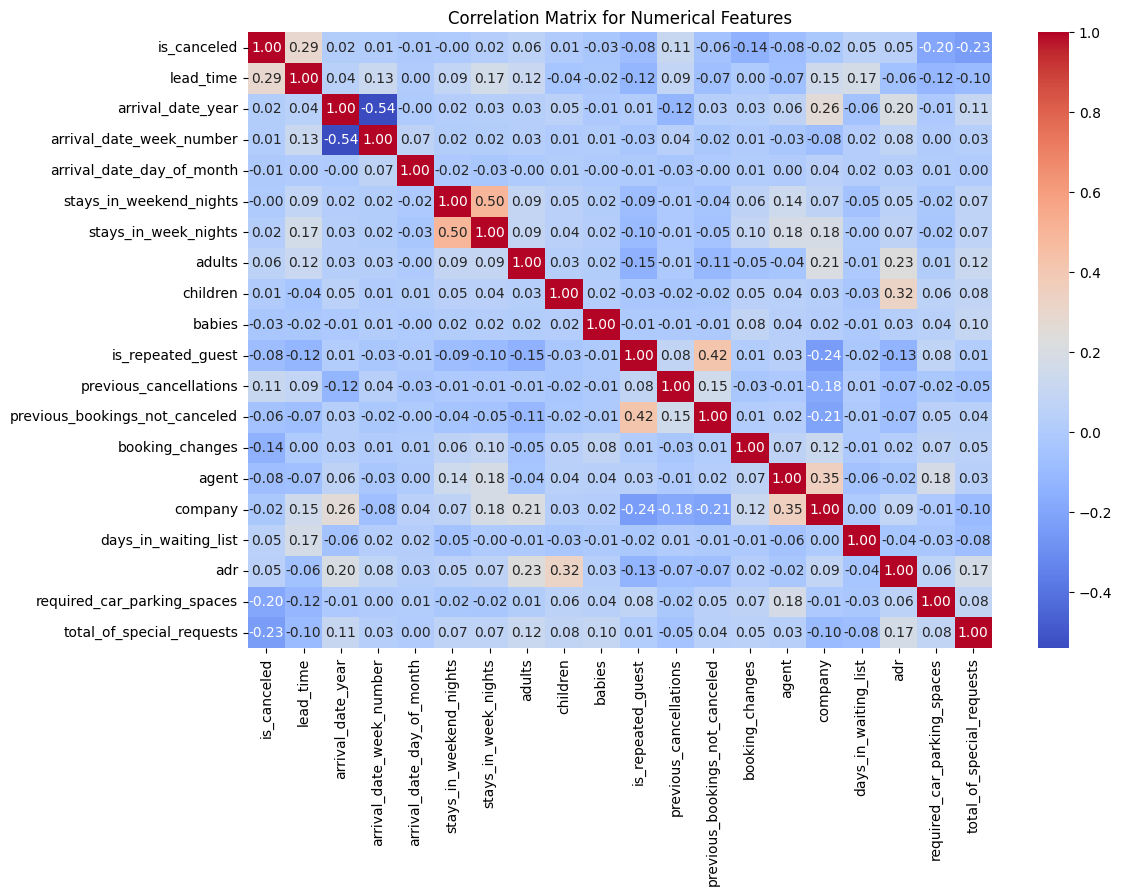

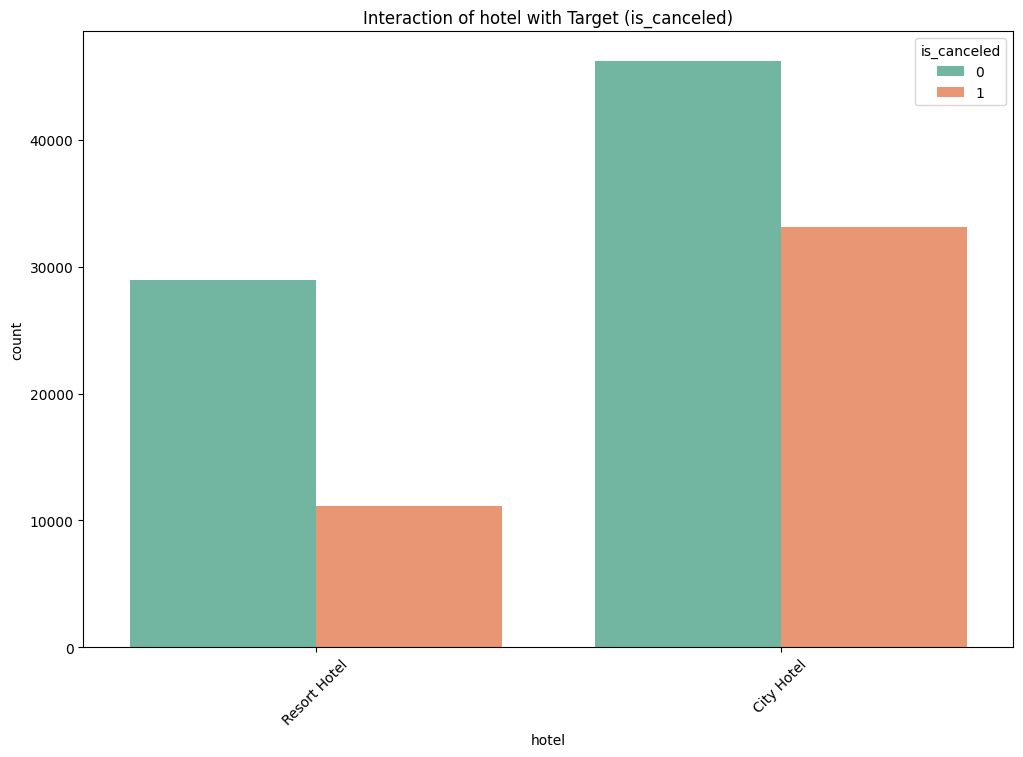

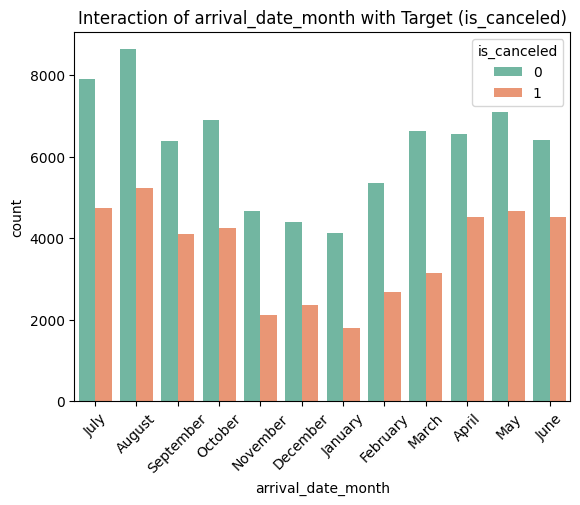

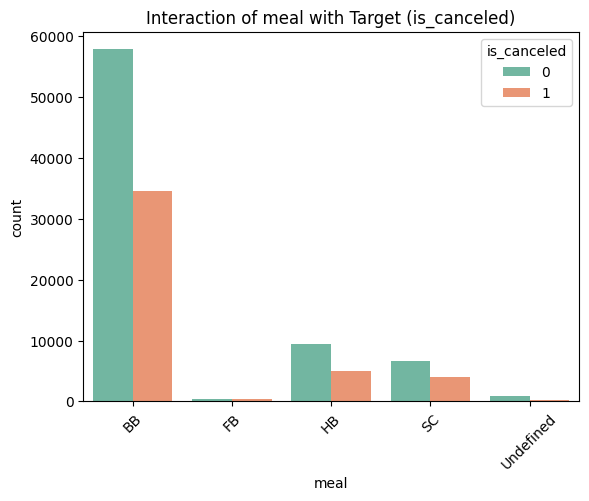

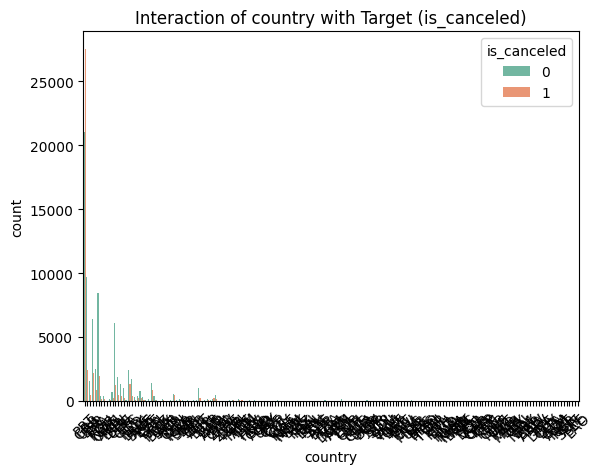

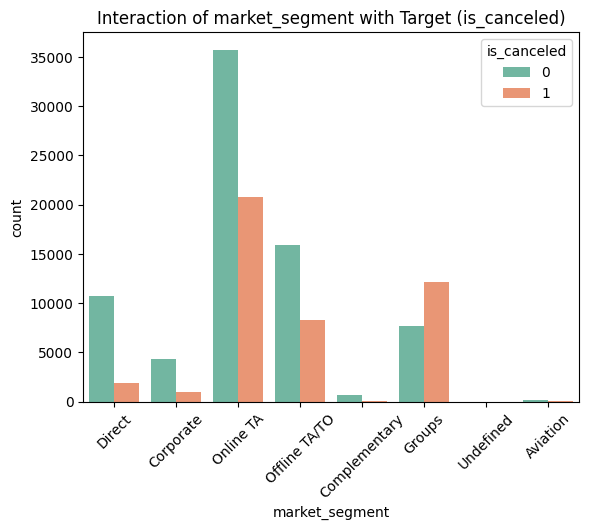

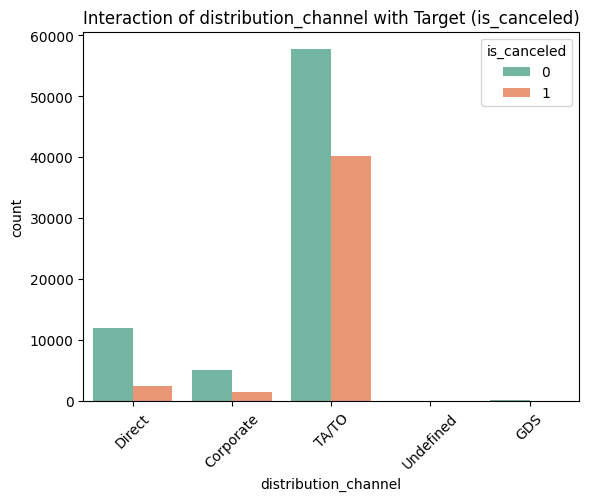

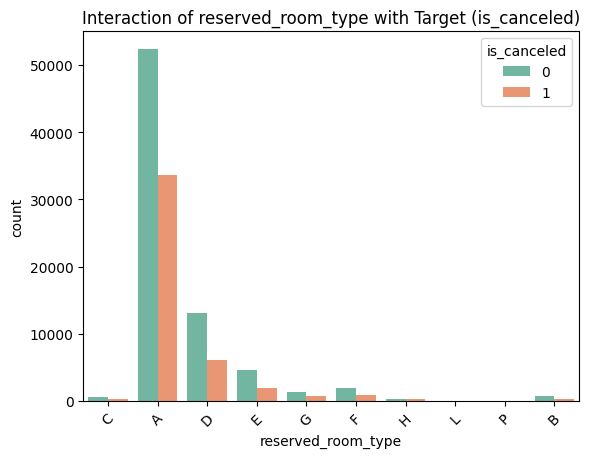

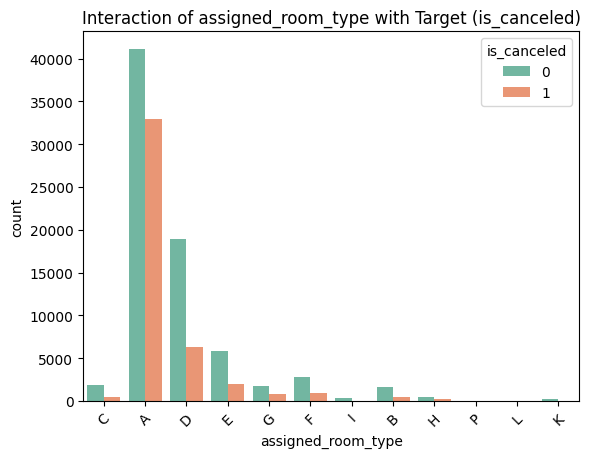

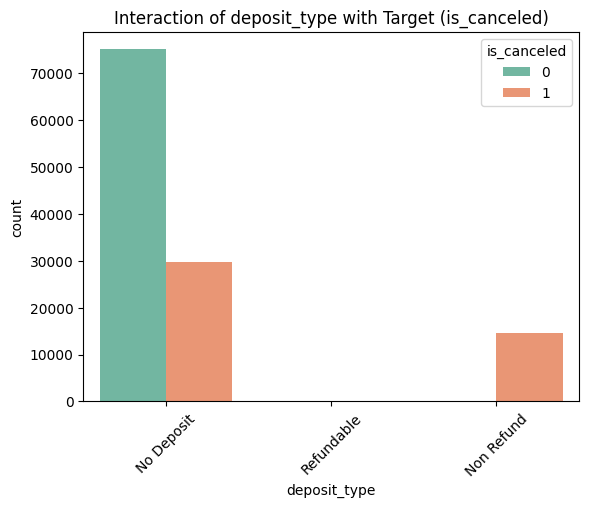

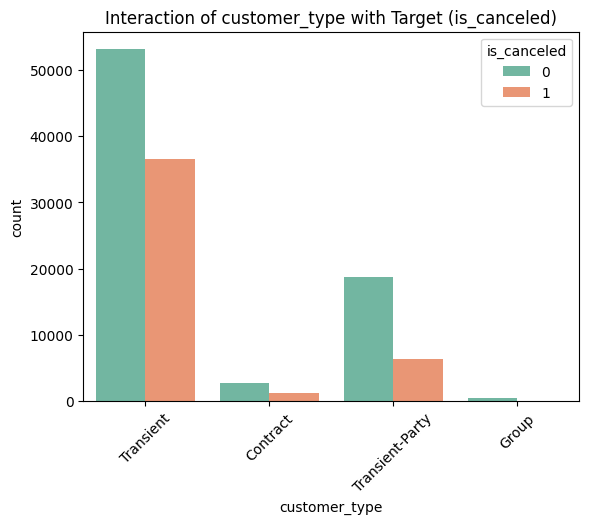

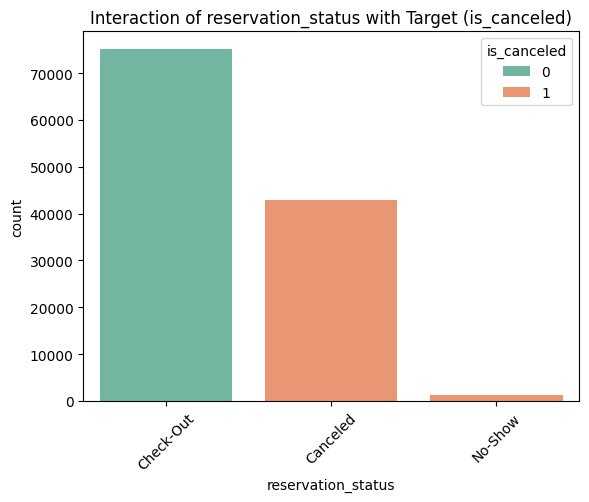

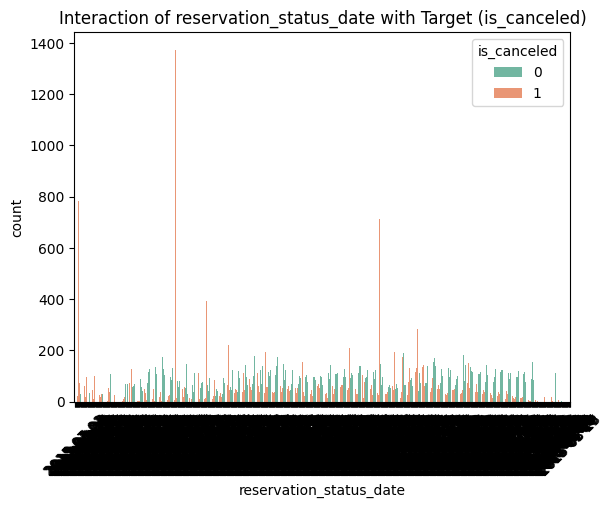

In [9]:
# Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix for Numerical Features")
plt.show()

# Interaction between categorical features
plt.figure(figsize=(12, 8))
for feature in categorical_features:
    sns.countplot(data=df, x=feature, hue="is_canceled", palette="Set2")
    plt.title(f"Interaction of {feature} with Target (is_canceled)")
    plt.xticks(rotation=45)
    plt.show()

To analyze the interactions and correlations, we can derive the following insights:

1. **Correlation Insights**:
    - The `correlation_matrix` shows how numerical features are related to each other and to the target variable (`is_canceled`).
    - Features like `lead_time` (0.293), `previous_cancellations` (0.110), and `total_of_special_requests` (-0.234) have notable correlations with `is_canceled`. This suggests that longer lead times and previous cancellations increase the likelihood of cancellation, while more special requests reduce it.
    - Features like `required_car_parking_spaces` (-0.195) and `booking_changes` (-0.144) also show moderate negative correlations with cancellations.

2. **Interaction Insights**:
    - The interaction plots between categorical features and `is_canceled` (e.g., `hotel`, `meal`, `market_segment`) reveal patterns in cancellation behavior.
    - For example, certain `market_segment` categories (like `Online TA`) may have higher cancellation rates compared to others (like `Corporate`).
    - Similarly, `deposit_type` interactions may show that bookings with no deposit are more likely to be canceled.



### Missing

In [10]:
# Calculate the number and percentage of missing values for each column
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100

# Create a DataFrame to display the missing values and their percentages
missing_values_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_values_percentage
}).sort_values(by='Missing Values', ascending=False)

# Display the table
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df

,Missing Values,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350



### Insights from Missing Values

1. **Children**:
    - Only 4 missing values (0.003% of the total data).
    - This is negligible and can be handled by imputation (e.g., replacing with the median or mode).

2. **Country**:
    - 488 missing values (0.41% of the total data).
    - Although the percentage is small, imputing these values with the most frequent country or a placeholder like "Unknown" can be considered.

3. **Agent**:
    - 16,340 missing values (13.69% of the total data).
    - This is a significant proportion. Missing values could indicate direct bookings or unknown agents. A placeholder value (e.g., 0 or "Unknown") might be appropriate.

4. **Company**:
    - 112,593 missing values (94.31% of the total data).
    - The majority of bookings lack company information, likely because they are individual bookings. This column may not be useful for modeling and could be dropped or treated as a categorical feature with a placeholder value.


In [11]:
# Handle missing values for 'children' (replace with median)
df['children'].fillna(df['children'].median(), inplace=True)

# Handle missing values for 'country' (replace with 'Unknown')
df['country'].fillna('Unknown', inplace=True)

# Handle missing values for 'agent' (replace with 0, assuming it indicates direct bookings)
df['agent'].fillna(0, inplace=True)

# Drop the 'company' column due to a high percentage of missing values
df.drop(columns=['company'], inplace=True)

# Verify the changes
print(df.isnull().sum())


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

C:\Users\eitank\AppData\Local\Temp\ipykernel_13028\2896491457.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(df['children'].median(), inplace=True)
C:\Users\eitank\AppData\Local\Temp\ipykernel_13028\2896491457.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [12]:
numerical_features.remove('company')


### Outliers

,Feature,Number of Outliers,Percentage
7,adults,29710,24.884831
13,booking_changes,18076,15.140297
8,children,8590,7.194907
17,required_car_parking_spaces,7416,6.211576
11,previous_cancellations,6484,5.430941
10,is_repeated_guest,3810,3.191222
16,adr,3793,3.176983
15,days_in_waiting_list,3698,3.097412
12,previous_bookings_not_canceled,3620,3.032080
6,stays_in_week_nights,3354,2.809281


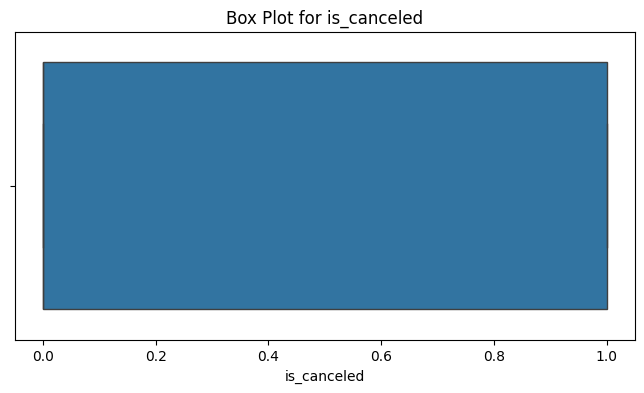

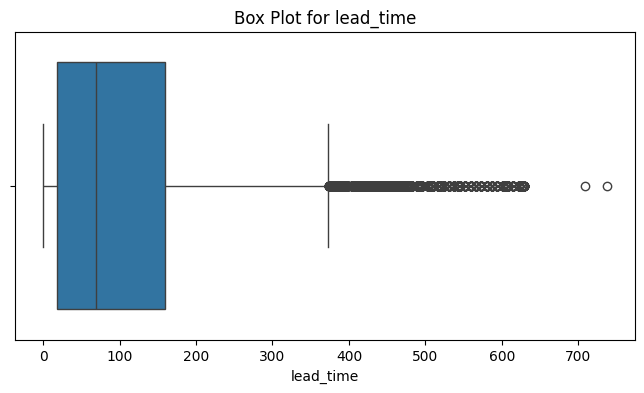

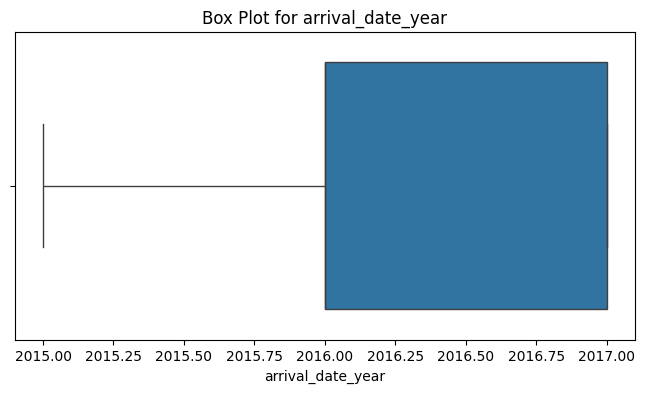

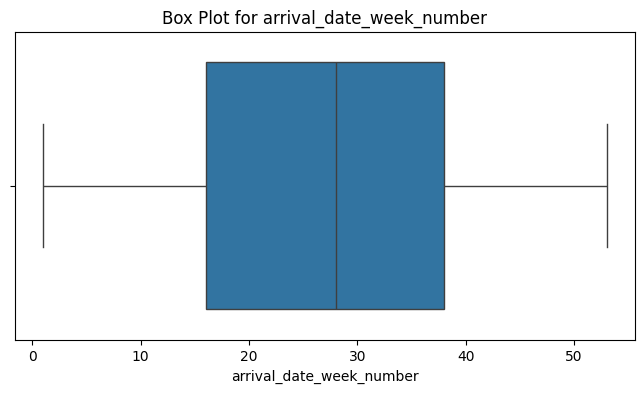

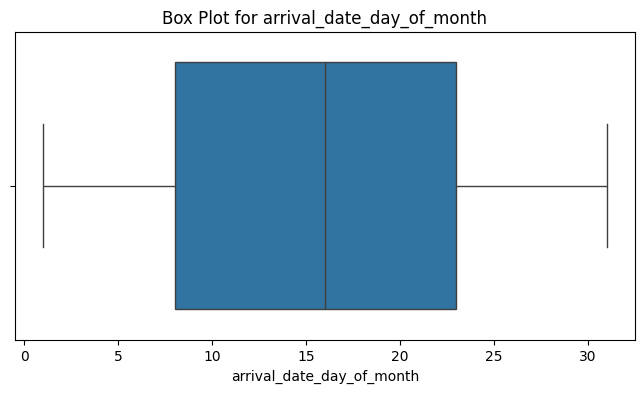

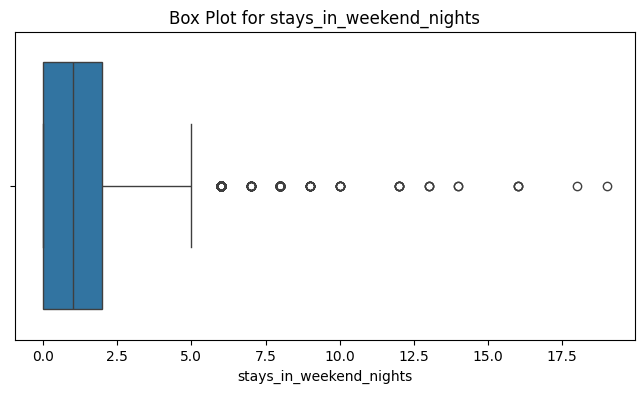

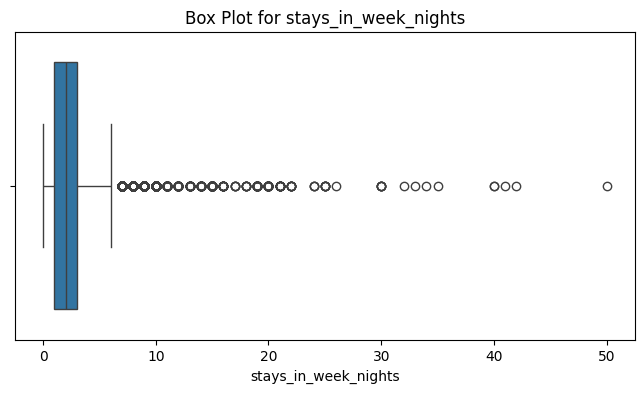

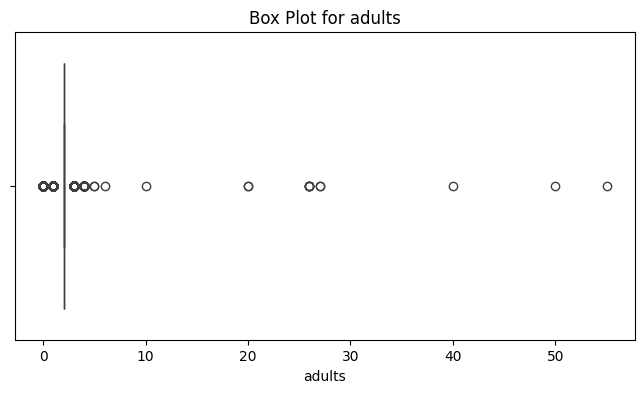

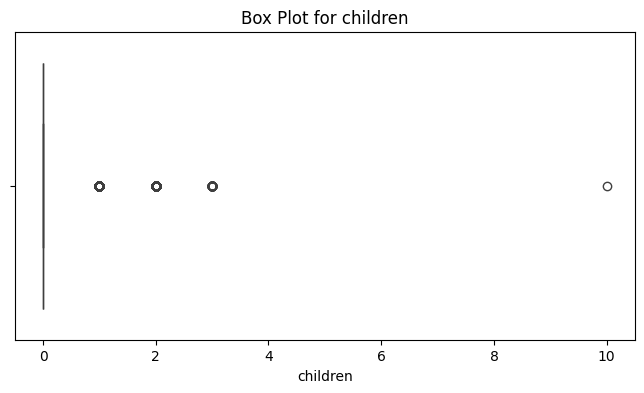

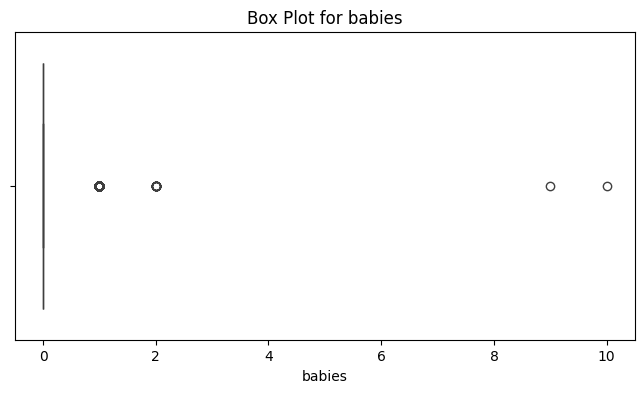

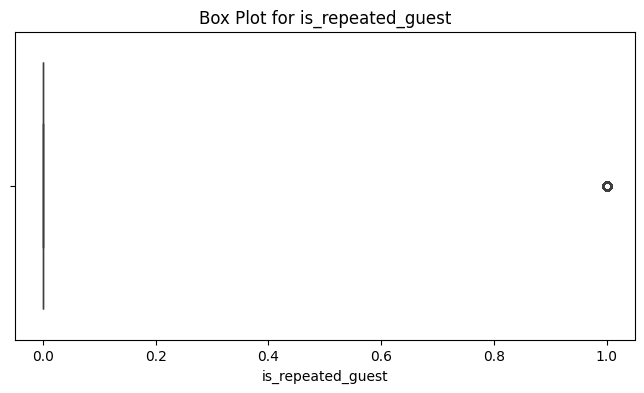

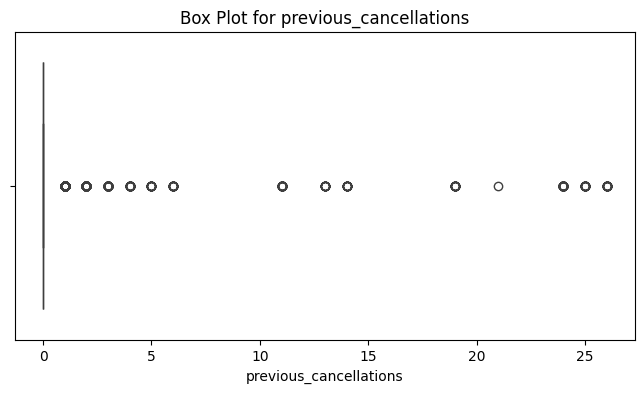

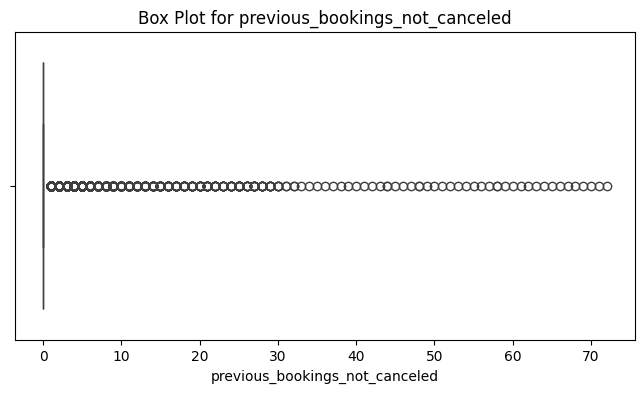

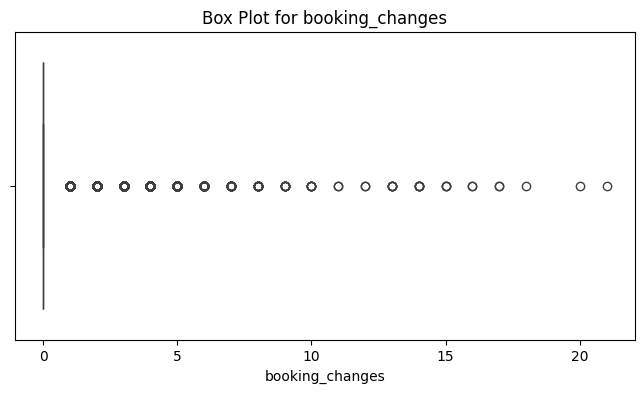

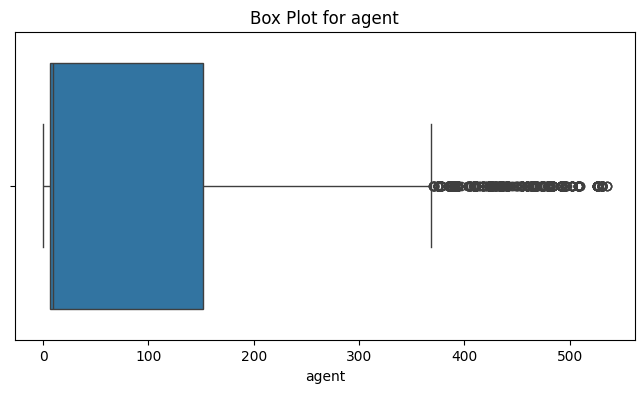

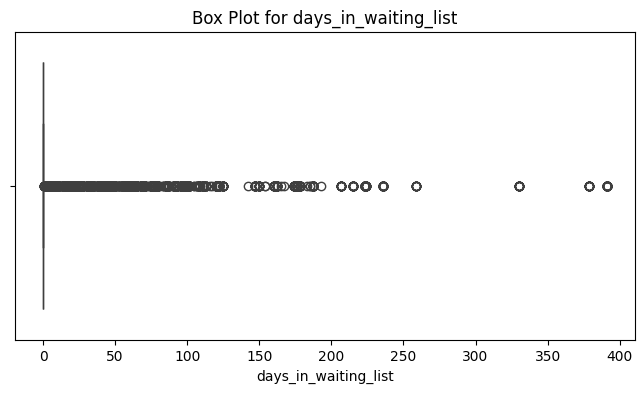

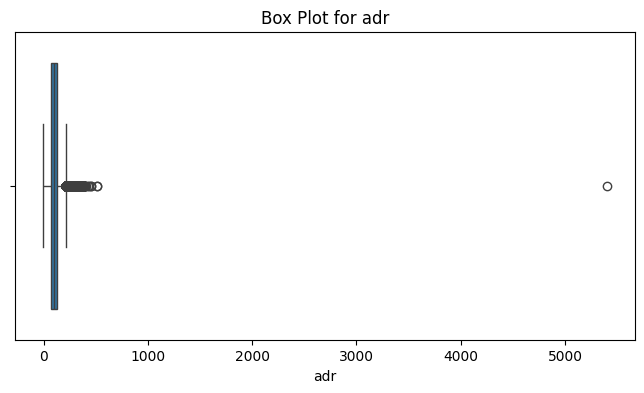

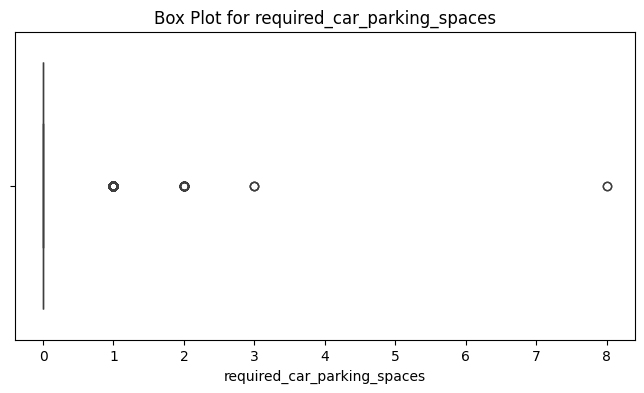

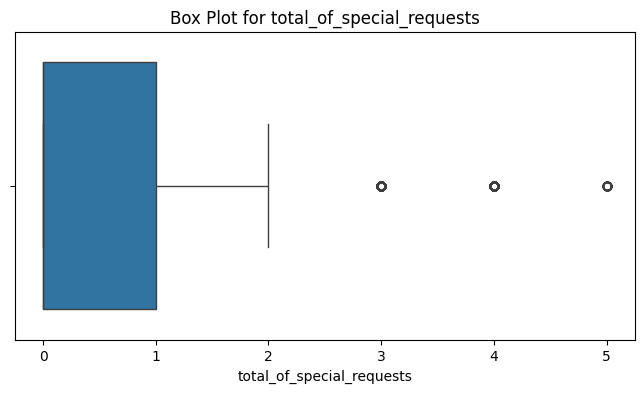

In [13]:
# Identify and handle outliers in numerical features

# Identify outliers in numerical features using the IQR method
outliers_summary = []
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outliers_count = len(outliers)
    outliers_percentage = outliers_count / len(df) * 100

    outliers_summary.append({
        'Feature': feature,
        'Number of Outliers': outliers_count,
        'Percentage': outliers_percentage
    })

# Convert the summary to a DataFrame for better visualization
outliers_summary_df = pd.DataFrame(outliers_summary).sort_values(by='Number of Outliers', ascending=False)

# Display the summary
display(outliers_summary_df.style.set_caption("Outliers Summary"))

# Visualize outliers using box plots
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=feature)
    plt.title(f"Box Plot for {feature}")
    # plt.show()



In [14]:
# Handle outliers for each numerical feature
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # For features with a high percentage of outliers, cap the values
    if feature in ['adults', 'booking_changes']:
        df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
        df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])
    # For features with a moderate percentage of outliers, remove the rows
    elif feature in ['children', 'required_car_parking_spaces', 'previous_cancellations']:
        df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    # For features with very few outliers, leave them as is
    else:
        pass

# Verify the changes
print("Number of rows after handling outliers:", len(df))


Number of rows after handling outliers: 98059


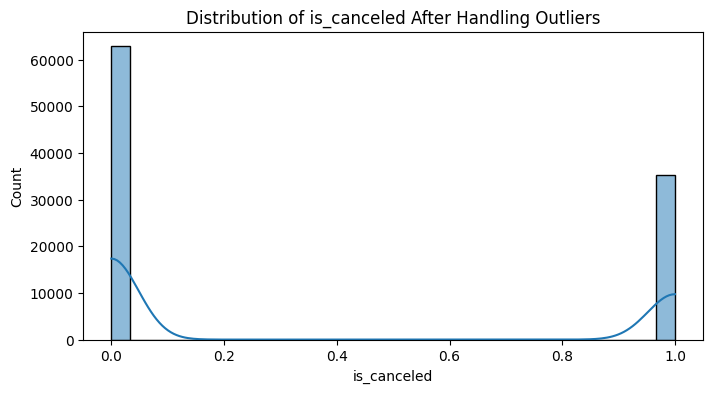

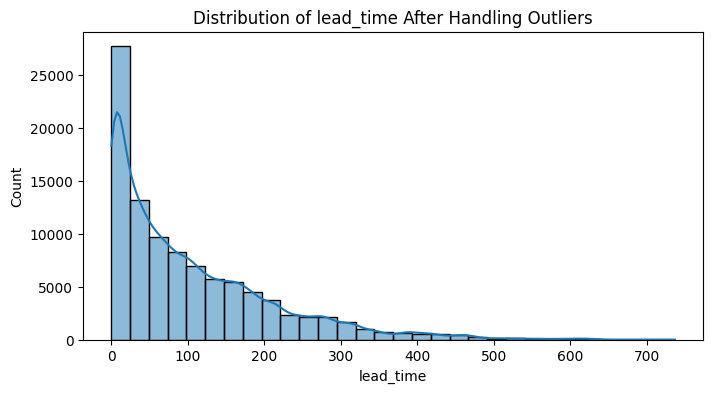

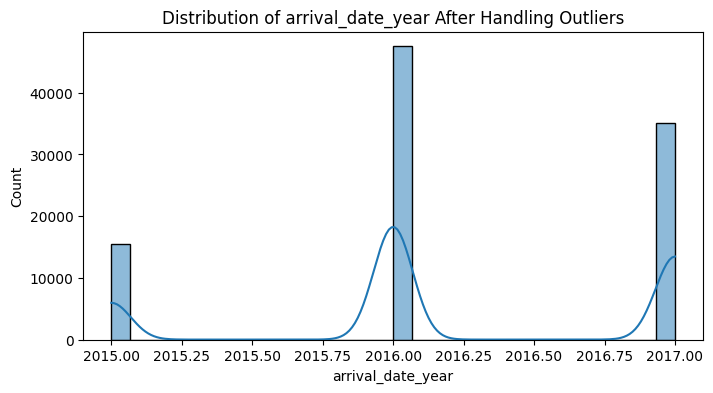

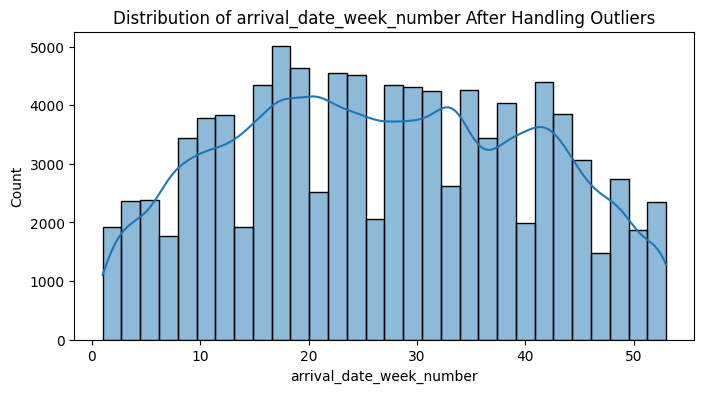

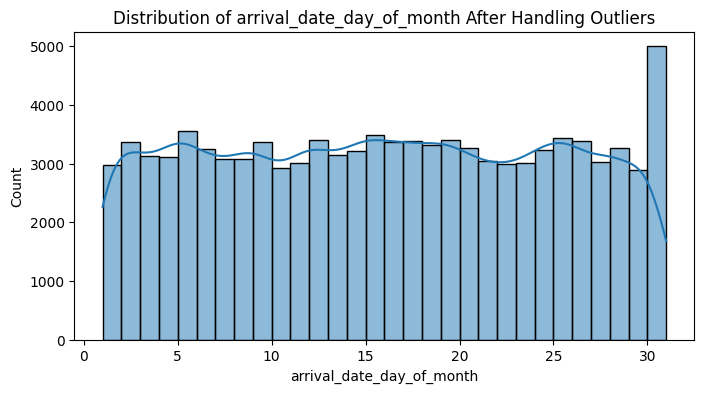

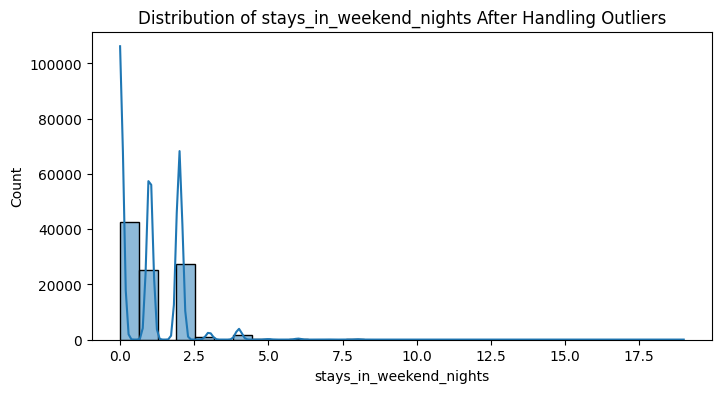

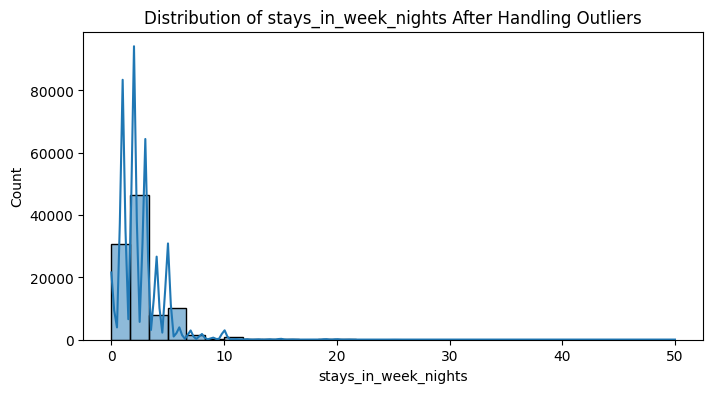

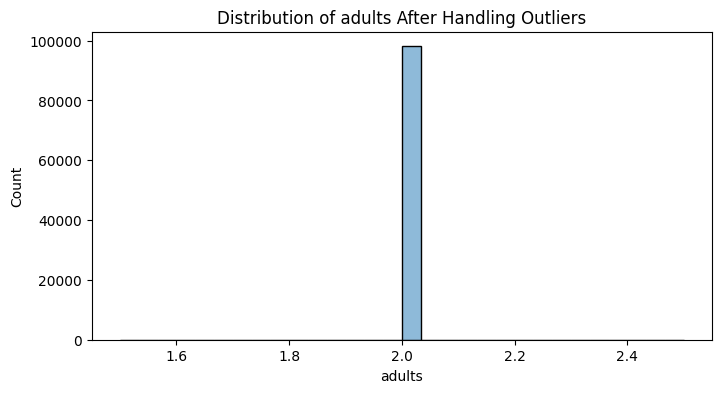

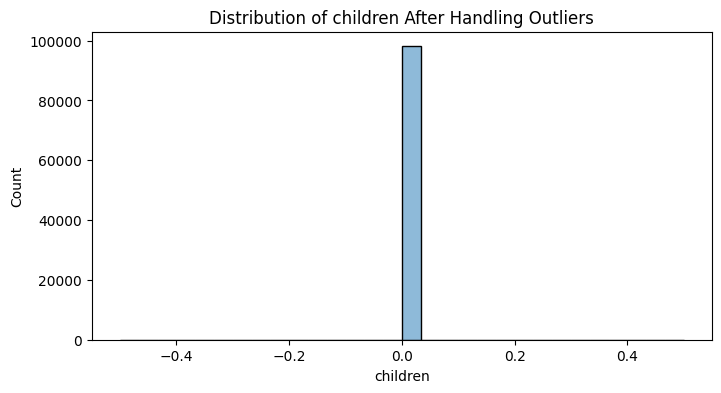

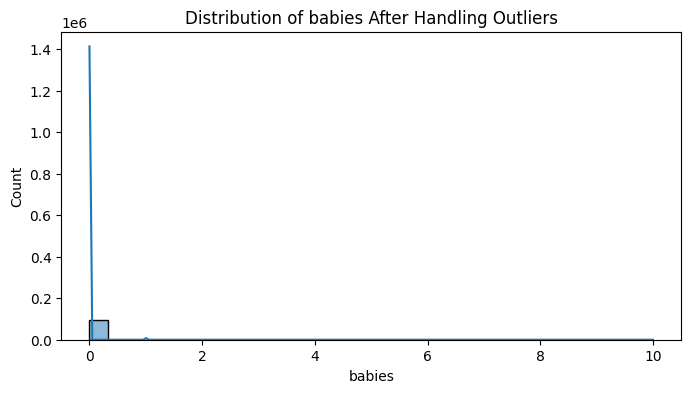

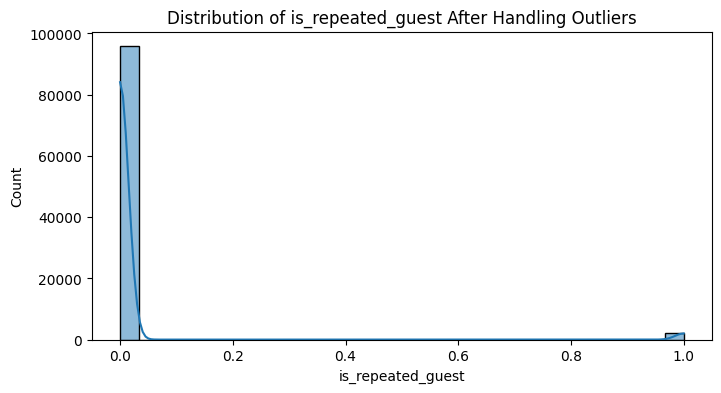

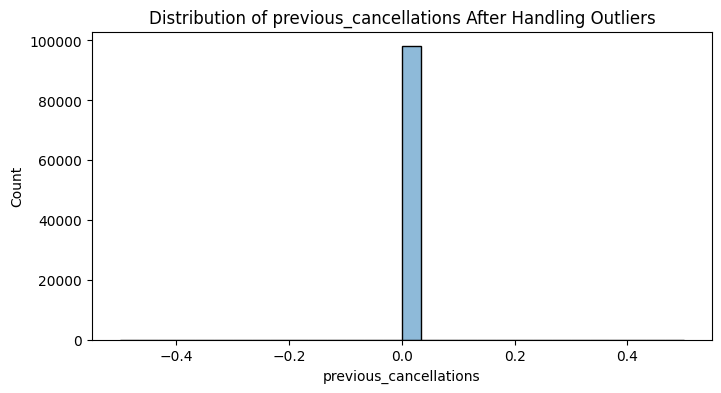

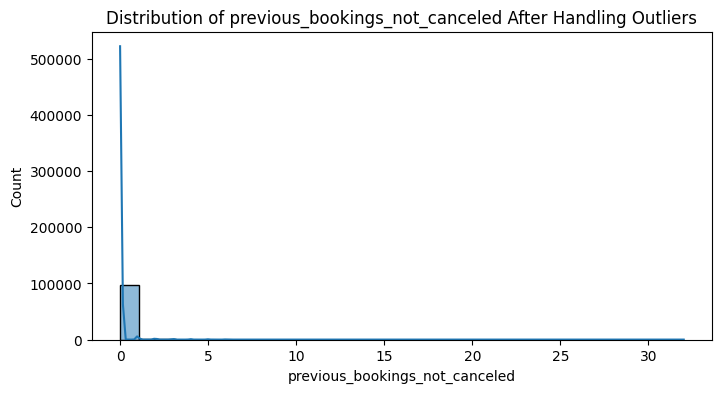

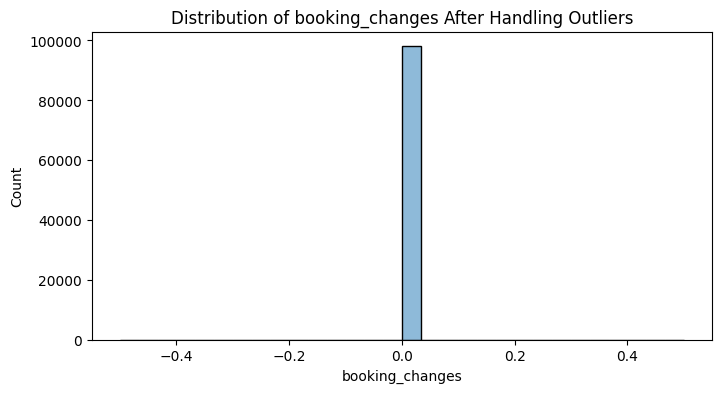

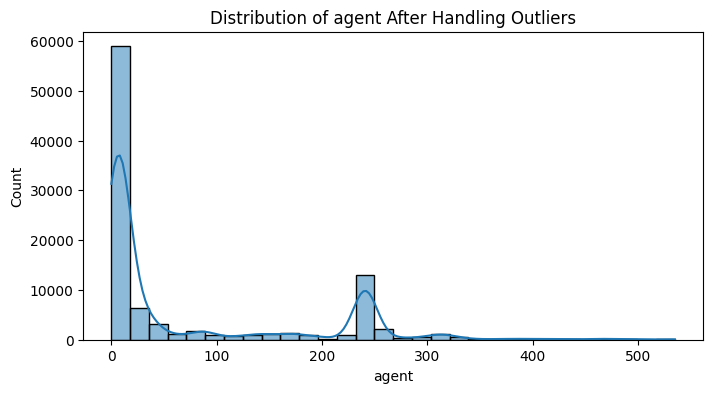

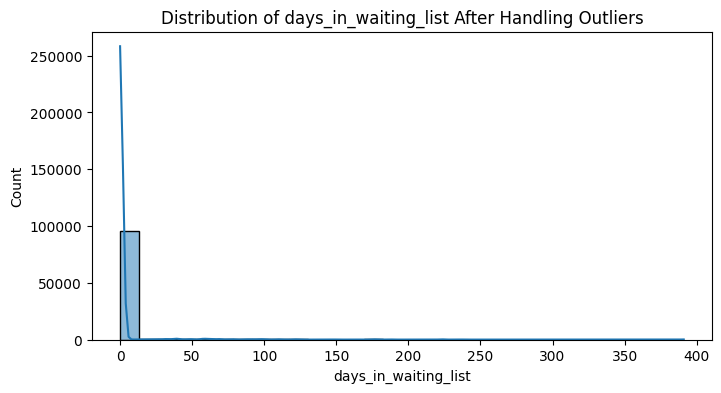

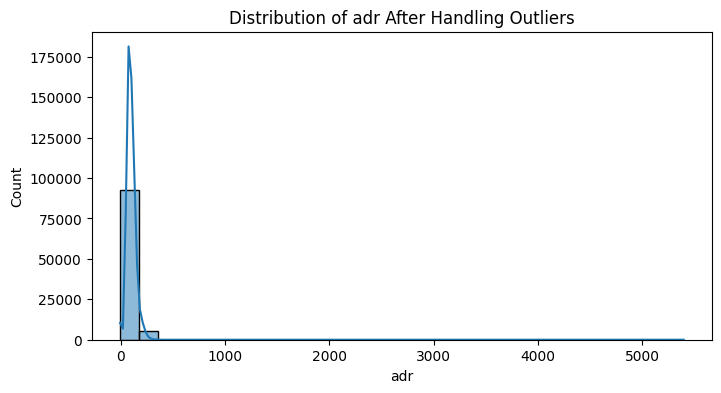

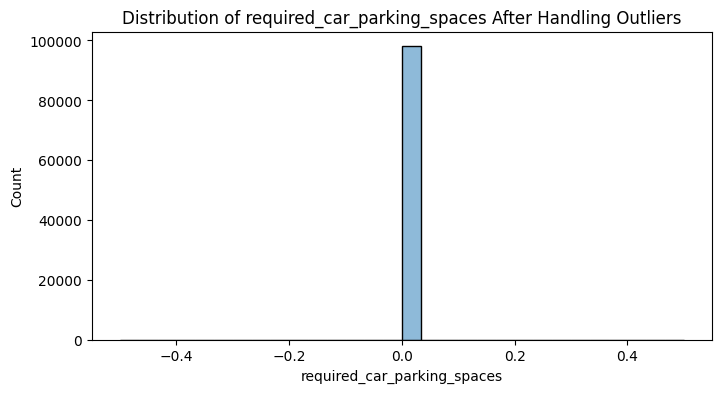

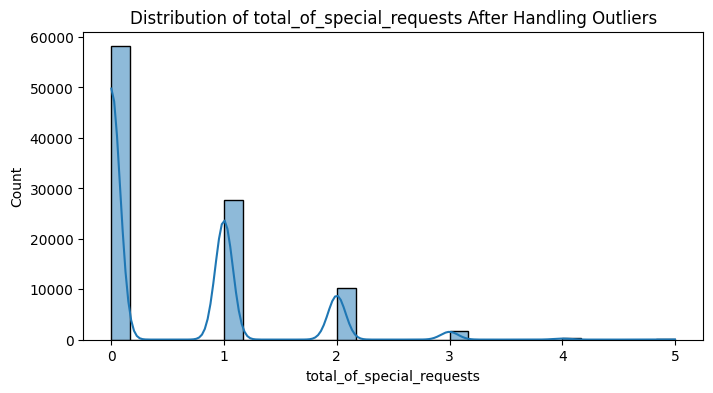

In [15]:
# Visualize the distribution of numerical features after handling outliers
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, bins=30, kde=True)
    plt.title(f"Distribution of {feature} After Handling Outliers")
    # plt.show()

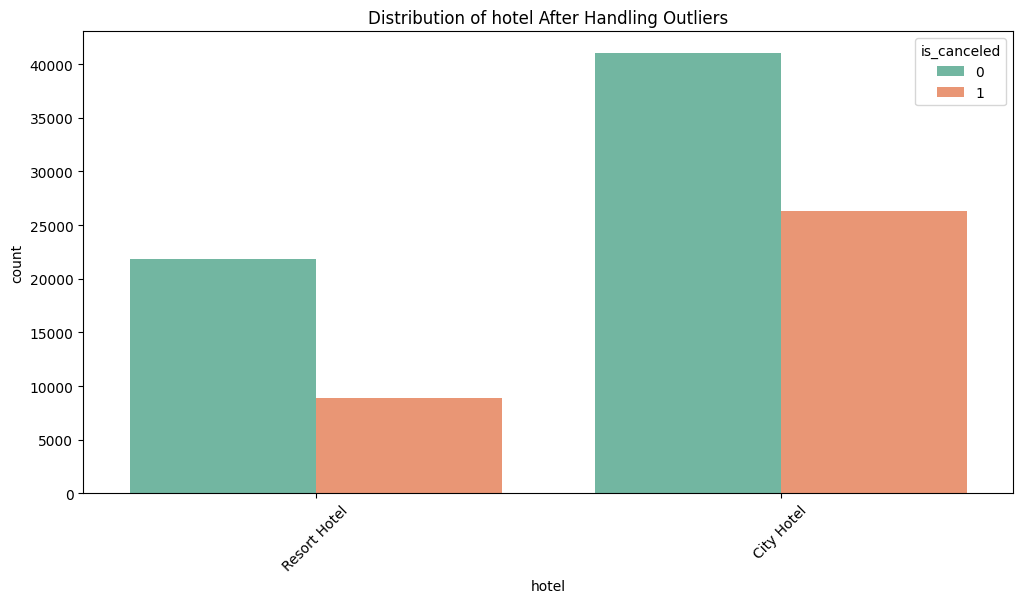

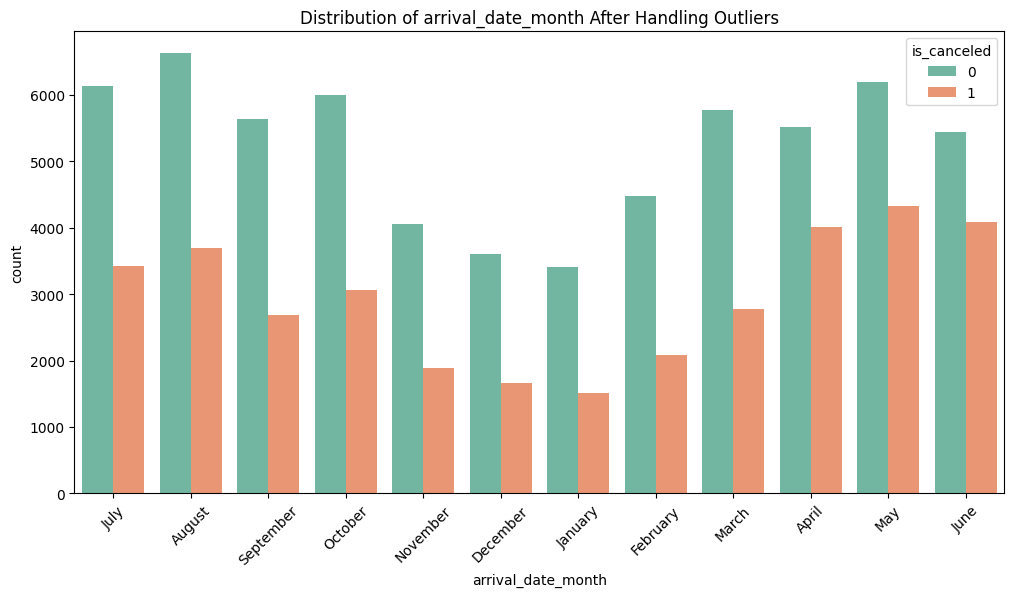

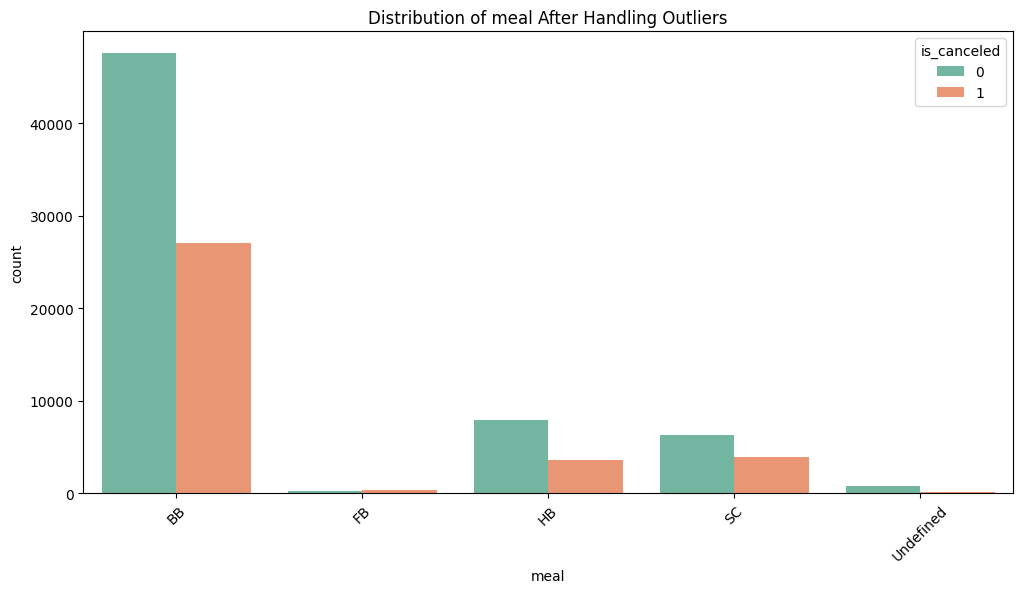

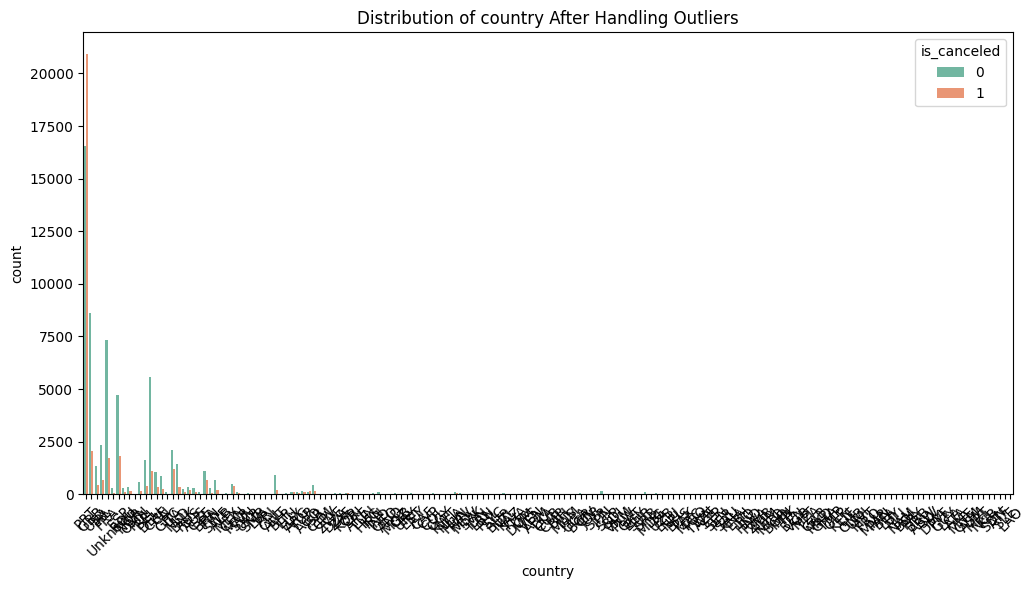

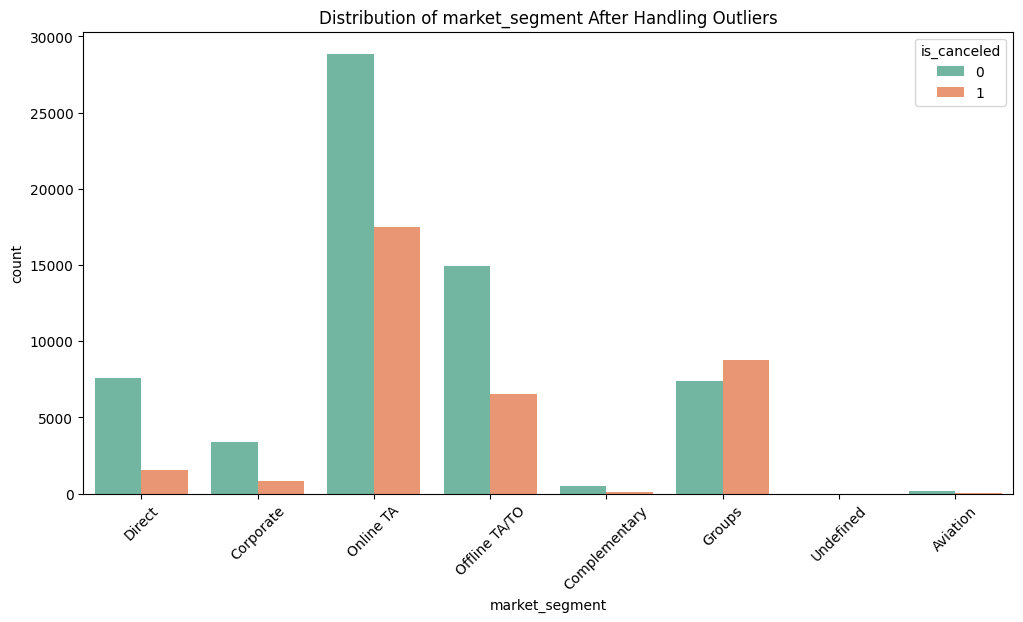

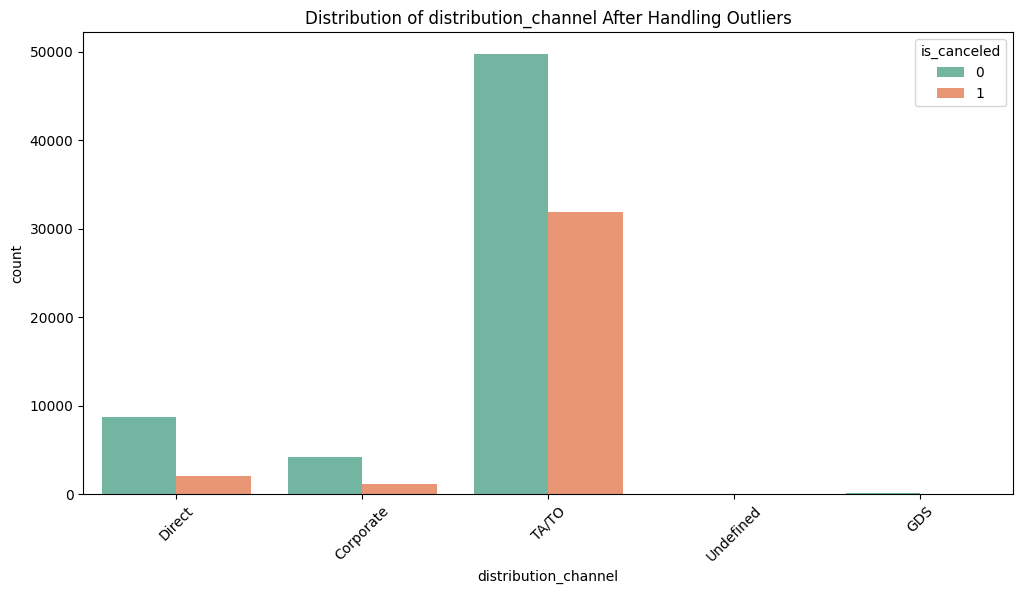

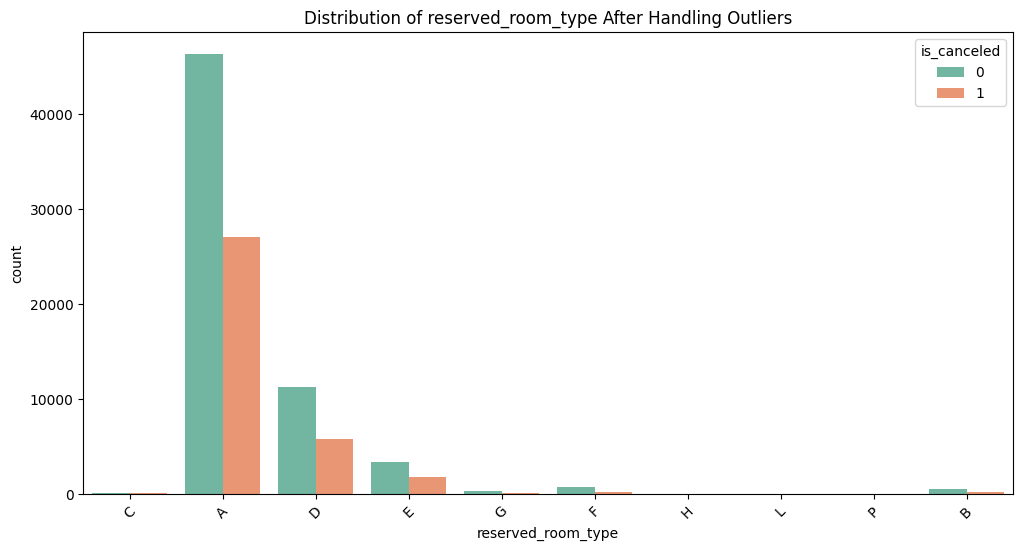

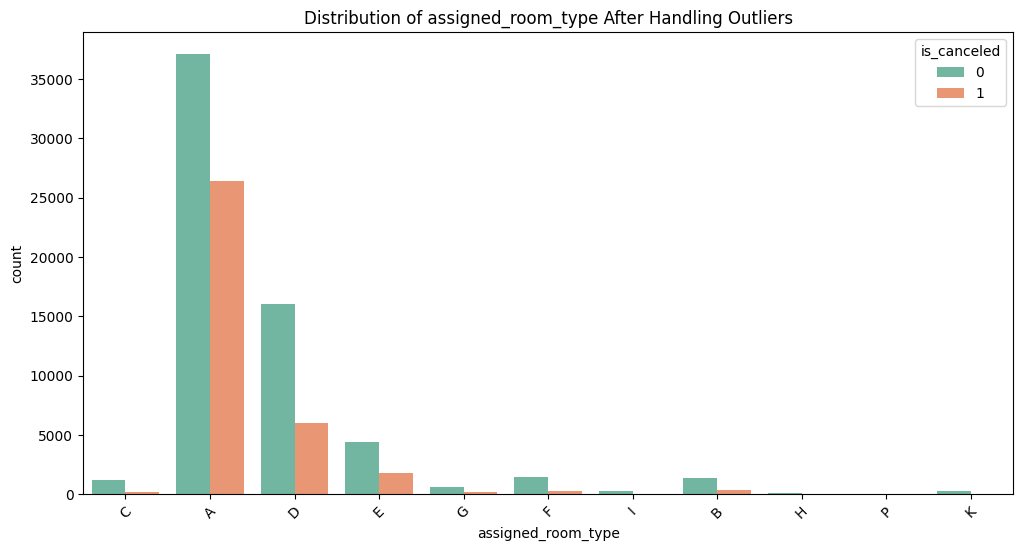

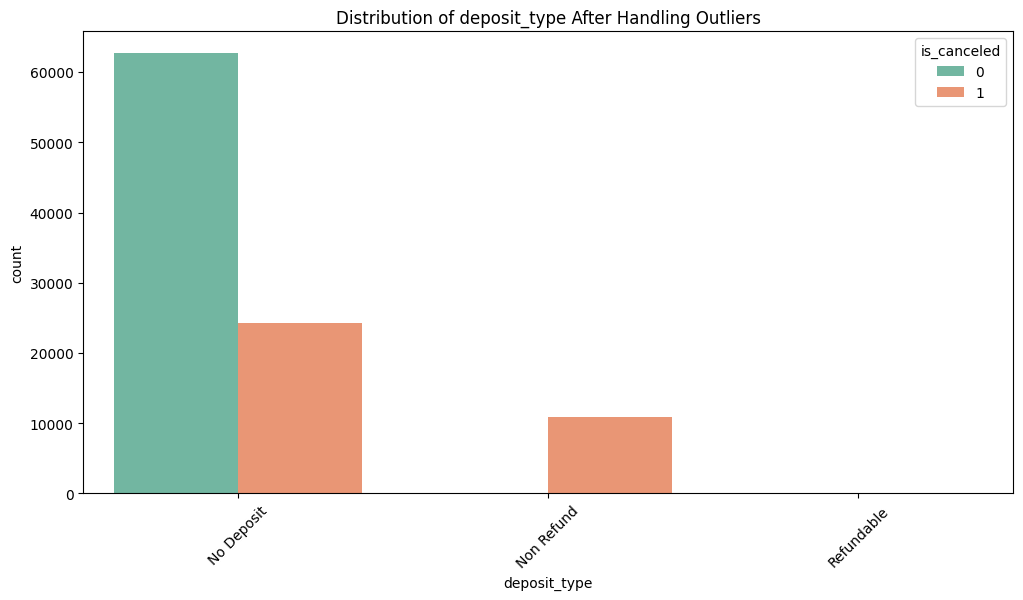

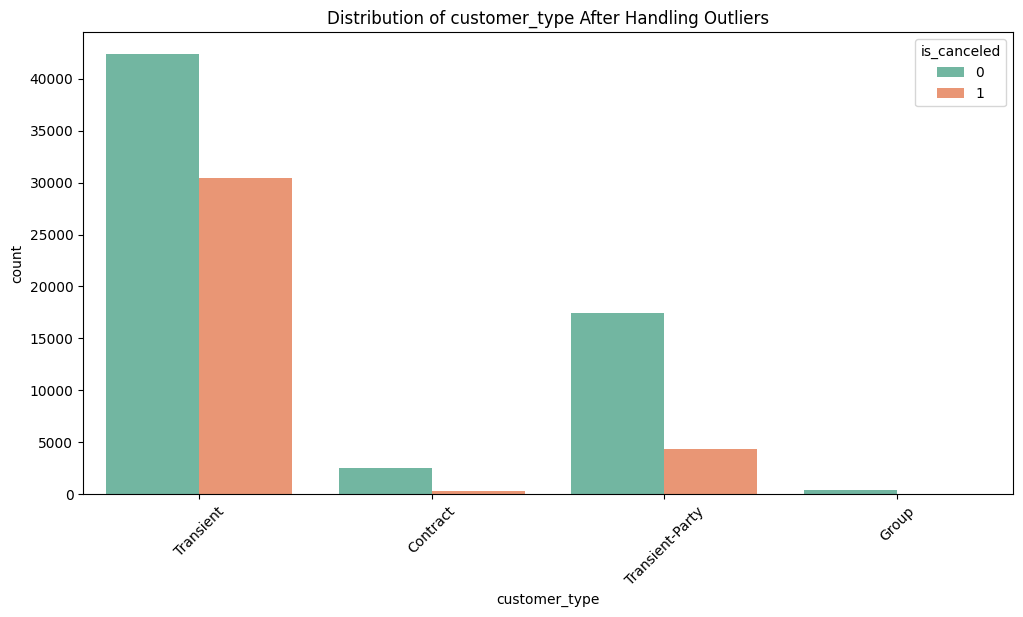

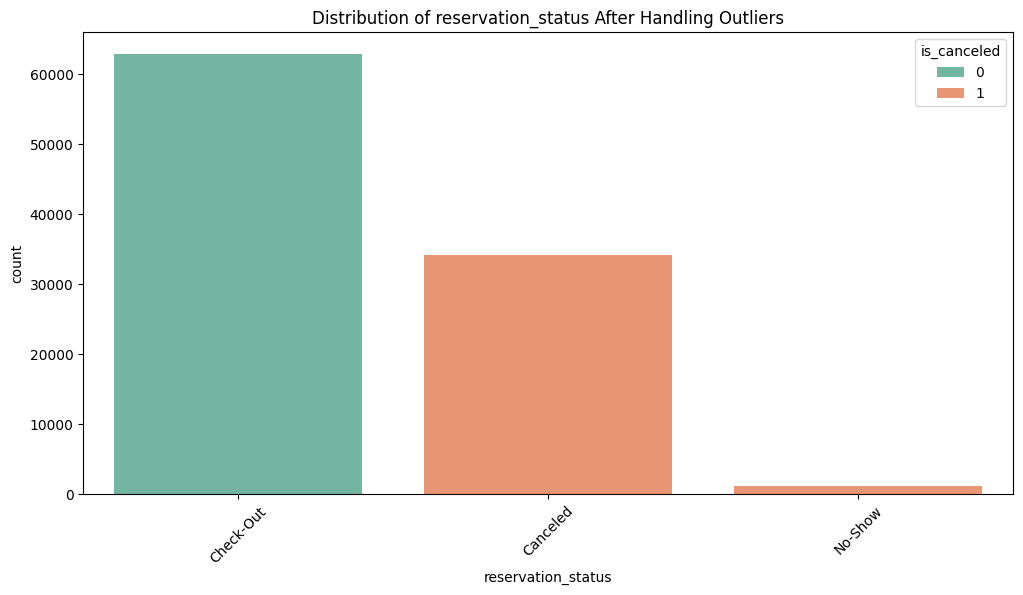

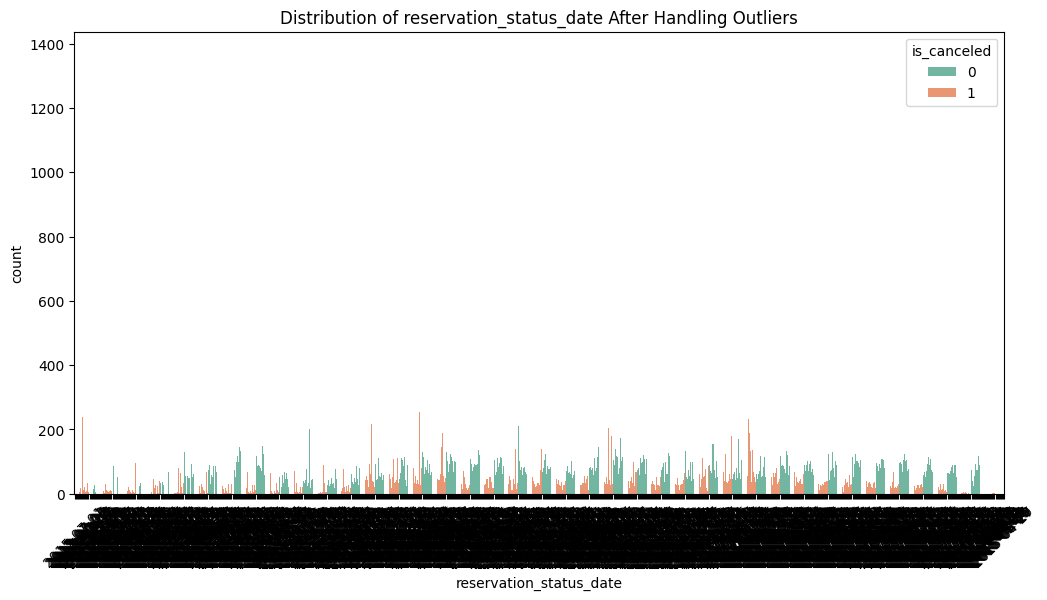

In [16]:
# Visualize the distribution of categorical features
for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=feature, hue="is_canceled", palette="Set2")
    plt.title(f"Distribution of {feature} After Handling Outliers")
    plt.xticks(rotation=45)
    plt.show()

### Duplicate Rows

In [17]:
# Check for duplicate rows in the dataset
print(f"Duplicate rows for non-canceled bookings: {df[df['is_canceled'] == 0].duplicated().sum()}")
print(f"Duplicate rows for canceled bookings: {df[df['is_canceled'] == 1].duplicated().sum()}")
print("*" * 100)

# Drop duplicate rows
df.drop_duplicates(inplace=True)
print("Duplicates dropped successfully.")
print("*" * 100)

# Verify if duplicates are removed
print(f"Duplicate rows for non-canceled bookings after cleaning: {df[df['is_canceled'] == 0].duplicated().sum()}")
print(f"Duplicate rows for canceled bookings after cleaning: {df[df['is_canceled'] == 1].duplicated().sum()}")

Duplicate rows for non-canceled bookings: 12462
Duplicate rows for canceled bookings: 15436
****************************************************************************************************
Duplicates dropped successfully.
****************************************************************************************************
Duplicate rows for non-canceled bookings after cleaning: 0
Duplicate rows for canceled bookings after cleaning: 0


 ### Feature Engineering

In [18]:
print("Numerical Features (Total: {}):".format(len(numerical_features)))
print(numerical_features)
print("\nCategorical Features (Total: {}):".format(len(categorical_features)))
print(categorical_features)

Numerical Features (Total: 19):
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Features (Total: 12):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


In [19]:
# Count the number of unique categories for each categorical feature
category_counts = df[categorical_features].nunique()

# Display the counts
print("Number of unique categories for each categorical feature:")
print(category_counts)

Number of unique categories for each categorical feature:
hotel                        2
arrival_date_month          12
meal                         5
country                    171
market_segment               8
distribution_channel         5
reserved_room_type          10
assigned_room_type          11
deposit_type                 3
customer_type                4
reservation_status           3
reservation_status_date    891
dtype: int64


In [20]:
# Check the data types of the columns after encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70161 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           70161 non-null  object 
 1   is_canceled                     70161 non-null  int64  
 2   lead_time                       70161 non-null  int64  
 3   arrival_date_year               70161 non-null  int64  
 4   arrival_date_month              70161 non-null  object 
 5   arrival_date_week_number        70161 non-null  int64  
 6   arrival_date_day_of_month       70161 non-null  int64  
 7   stays_in_weekend_nights         70161 non-null  int64  
 8   stays_in_week_nights            70161 non-null  int64  
 9   adults                          70161 non-null  float64
 10  children                        70161 non-null  float64
 11  babies                          70161 non-null  int64  
 12  meal                            7016

 Select relevant categorical features based on domain knowledge or feature importance
 These features were chosen because they are likely to have a significant impact on the target variable (`is_canceled`).
 For example:
 - `hotel`: Different hotels may have different cancellation rates.
 - `meal`: The type of meal plan might influence cancellations.
 - `market_segment` and `distribution_channel`: These indicate how the booking was made, which could affect cancellations.
 - `reserved_room_type` and `deposit_type`: These may reflect customer preferences and commitment levels.
 - `customer_type`: Different customer types (e.g., transient, group) may have varying cancellation behaviors.


 Other features like `country`, `assigned_room_type`, and `reservation_status` were excluded because:
 - `country`: High cardinality, which may not add significant predictive power.
 - `assigned_room_type`: Strong correlation with `reserved_room_type`, leading to redundancy.
 - `reservation_status`: Post-booking information, not available at the time of prediction.
 - `reservation_status_date`: Not relevant for prediction, as it is a timestamp of the status.


In [21]:
relevant_categorical_features = ['hotel', 'meal', 'market_segment', 'distribution_channel', 
                                  'reserved_room_type', 'deposit_type', 'customer_type','arrival_date_month']


# Perform one-hot encoding on the selected relevant categorical features
df_encoded = pd.get_dummies(df, columns=relevant_categorical_features, drop_first=True)

# Alternative encoding for 'country' (e.g., frequency encoding)
country_counts = df['country'].value_counts()
df_encoded['country_encoded'] = df['country'].map(country_counts)

# Update the dataframe
# df = pd.concat([df, df_encoded], axis=1)
df = df_encoded.copy()


# Display the first few rows of the updated dataframe
df.head()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,arrival_date_month_February,arrival_date_month_January,arrival_date_month_July,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,country_encoded
0,0,342,2015,27,1,0,0,2.0,0.0,0,...,False,False,True,False,False,False,False,False,False,20682
1,0,737,2015,27,1,0,0,2.0,0.0,0,...,False,False,True,False,False,False,False,False,False,20682
2,0,7,2015,27,1,0,1,2.0,0.0,0,...,False,False,True,False,False,False,False,False,False,8989
3,0,13,2015,27,1,0,1,2.0,0.0,0,...,False,False,True,False,False,False,False,False,False,8989
4,0,14,2015,27,1,0,2,2.0,0.0,0,...,False,False,True,False,False,False,False,False,False,8989


In [22]:
# Feature Engineering

# 1. Create a new feature for total guests (adults + children + babies)
df['total_guests'] = df[['adults', 'children', 'babies']].sum(axis=1)

# 2. Create a new feature for total stay duration (weekend nights + week nights)
df['total_stay'] = df[['stays_in_weekend_nights', 'stays_in_week_nights']].sum(axis=1)

# 3. Create a new feature for average daily rate per person
df['adr_per_person'] = df['adr'] / df['total_guests']
df['adr_per_person'].replace([np.inf, -np.inf], 0, inplace=True)  # Handle division by zero

# # 4. Encode categorical features using one-hot encoding
# df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# # Add the encoded features back to the dataframe
# df = pd.concat([df, df_encoded], axis=1)

# # 5. Convert 'reservation_status_date' to datetime format and extract year, month, and day
# df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
# df['reservation_status_year'] = df['reservation_status_date'].dt.year
# df['reservation_status_month'] = df['reservation_status_date'].dt.month
# df['reservation_status_day'] = df['reservation_status_date'].dt.day

# 6. Drop unnecessary columns
# columns_to_drop = ['reservation_status_date',  'arrival_date_month']
columns_to_drop = ['assigned_room_type','reservation_status','reservation_status_date','country']
df.drop(columns=columns_to_drop, inplace=True)

# Add the new features to the dataframe
numerical_features.extend(['total_guests', 'total_stay', 'adr_per_person'])
categorical_features.extend(['reservation_status_year', 'reservation_status_month', 'reservation_status_day'])

# Convert all boolean columns to integer type
bool_columns = df.select_dtypes(include=['bool']).columns
df[bool_columns] = df[bool_columns].astype(int)

# Verify the changes
df.head()

C:\Users\eitank\AppData\Local\Temp\ipykernel_13028\2097480891.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['adr_per_person'].replace([np.inf, -np.inf], 0, inplace=True)  # Handle division by zero


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,country_encoded,total_guests,total_stay,adr_per_person
0,0,342,2015,27,1,0,0,2.0,0.0,0,...,0,0,0,0,0,0,20682,2.0,0,0.0
1,0,737,2015,27,1,0,0,2.0,0.0,0,...,0,0,0,0,0,0,20682,2.0,0,0.0
2,0,7,2015,27,1,0,1,2.0,0.0,0,...,0,0,0,0,0,0,8989,2.0,1,37.5
3,0,13,2015,27,1,0,1,2.0,0.0,0,...,0,0,0,0,0,0,8989,2.0,1,37.5
4,0,14,2015,27,1,0,2,2.0,0.0,0,...,0,0,0,0,0,0,8989,2.0,2,49.0


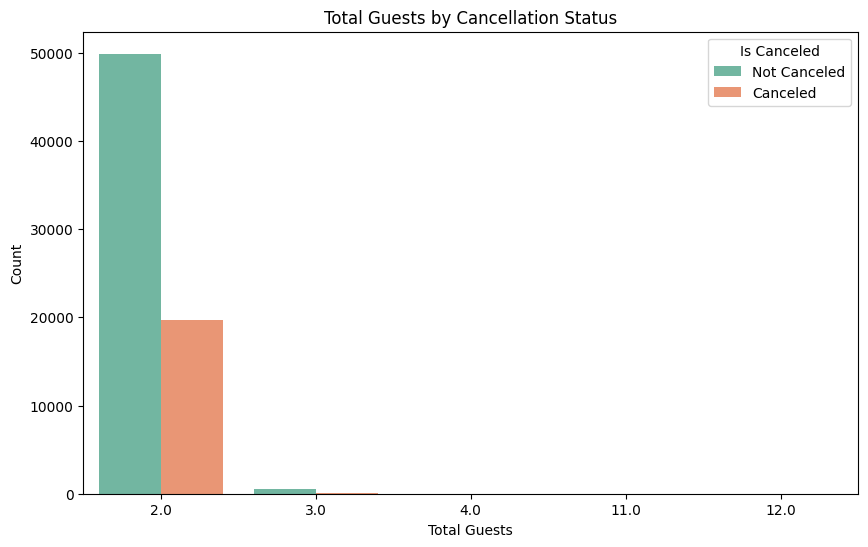

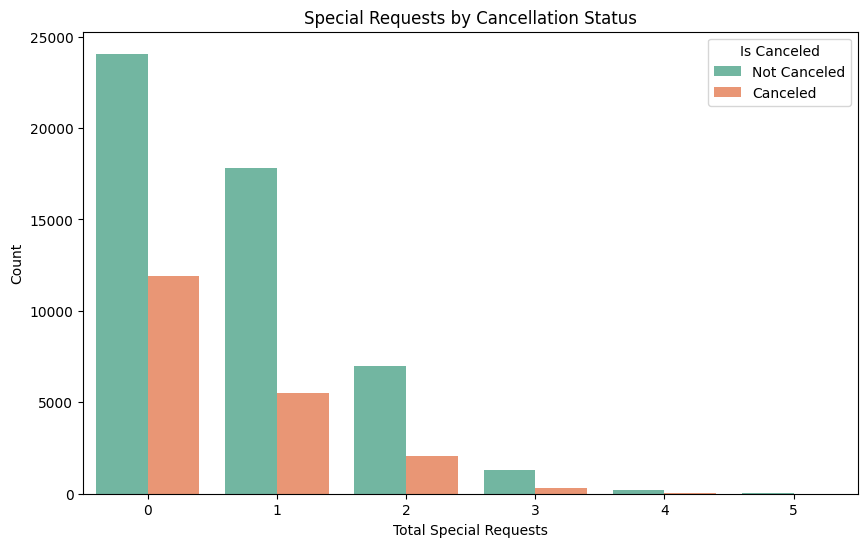

In [23]:


# Visualize the relationship between total_guests and is_canceled
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='total_guests', hue='is_canceled', palette='Set2')
plt.title("Total Guests by Cancellation Status")
plt.xlabel("Total Guests")
plt.ylabel("Count")
plt.legend(title="Is Canceled", labels=["Not Canceled", "Canceled"])
plt.show()


# Visualize the relationship between total_of_special_requests and is_canceled
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='total_of_special_requests', hue='is_canceled', palette='Set2')
plt.title("Special Requests by Cancellation Status")
plt.xlabel("Total Special Requests")
plt.ylabel("Count")
plt.legend(title="Is Canceled", labels=["Not Canceled", "Canceled"])
plt.show()

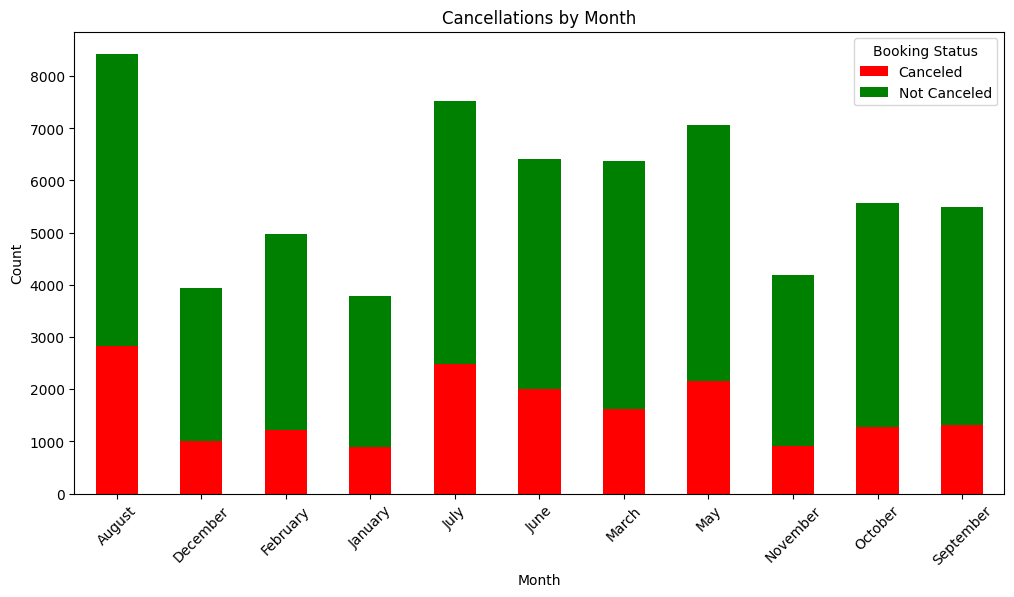

In [24]:
# Plot the relationship between arrival_date_month and is_canceled using one-hot encoded columns
month_columns = [col for col in df.columns if col.startswith('arrival_date_month_')]
month_cancellation_counts = df[df['is_canceled'] == 1][month_columns].sum()
month_not_cancellation_counts = df[df['is_canceled'] == 0][month_columns].sum()

# Combine the counts into a DataFrame for plotting
month_data = pd.DataFrame({
    'Canceled': month_cancellation_counts,
    'Not Canceled': month_not_cancellation_counts
}).sort_index()

# Plot the data
month_data.plot(kind='bar', figsize=(12, 6), stacked=True, color=['red', 'green'])
plt.title("Cancellations by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(ticks=range(len(month_columns)), labels=[col.split('_')[-1] for col in month_columns], rotation=45)
plt.legend(title="Booking Status")
plt.show()





 **Cancellation Rates**:
    - The proportion of cancellations varies by month. For example, **June** and **July** show a relatively higher number of cancellations compared to other months.
    - Months like **December** and **November** have fewer cancellations, indicating that bookings during these months might be more stable.


From the feature engineering process, you can learn the following:

1. **New Features Creation**:
    - **`total_guests`**: Combining `adults`, `children`, and `babies` into a single feature helps capture the total number of guests in a booking, which may influence cancellations.
    - **`total_stay`**: Summing `stays_in_weekend_nights` and `stays_in_week_nights` provides the total duration of the stay, which could correlate with cancellation behavior.
    - **`adr_per_person`**: Calculating the average daily rate per person gives a normalized cost metric, which might reveal patterns in cancellations based on pricing.

2. **Categorical Encoding**:
    - One-hot encoding of selected relevant categorical features (e.g., `hotel`, `meal`, `market_segment`, `distribution_channel`, `reserved_room_type`, `deposit_type`, `customer_type`, `arrival_date_month`) allows machine learning models to process these variables effectively.
    - Frequency encoding was applied to the `country` feature to handle its high cardinality.

3. **Feature Reduction**:
    - Dropping unnecessary columns (e.g., `assigned_room_type`, `reservation_status`, `reservation_status_date`, `country`) reduces dimensionality and avoids redundancy.

4. **Data Normalization**:
    - Handling division by zero in `adr_per_person` ensures data consistency and prevents errors during modeling.

These steps improve the dataset's quality, enhance interpretability, and prepare it for machine learning models.



1. **Seasonal Trends**:
    - Certain months, such as **June**, **July**, and **May**, have higher counts of both canceled and non-canceled bookings. This indicates that these months are likely peak seasons for hotel bookings.
    - Months like **January**, **February**, and **November** have lower booking counts, suggesting they might be off-peak seasons.

2. **Cancellation Rates**:
    - The proportion of cancellations varies by month. For example, **June** and **July** show a relatively higher number of cancellations compared to other months.
    - Months like **December** and **November** have fewer cancellations, indicating that bookings during these months might be more stable.

3. **Operational Insights**:
    - Hotels can use this information to adjust their strategies during peak months with high cancellations, such as overbooking policies or offering incentives to reduce cancellations.
    - For months with lower cancellations, hotels might focus on increasing overall bookings through promotions or discounts.

This analysis highlights the importance of understanding seasonal patterns to optimize hotel operations and revenue management.

### Imbalance data

The dataset is imbalanced, with a higher proportion of non-canceled bookings (`is_canceled = 0`) compared to canceled bookings (`is_canceled = 1`).

19774 Canceled (28.18%)
50387 Not Canceled (71.82%)


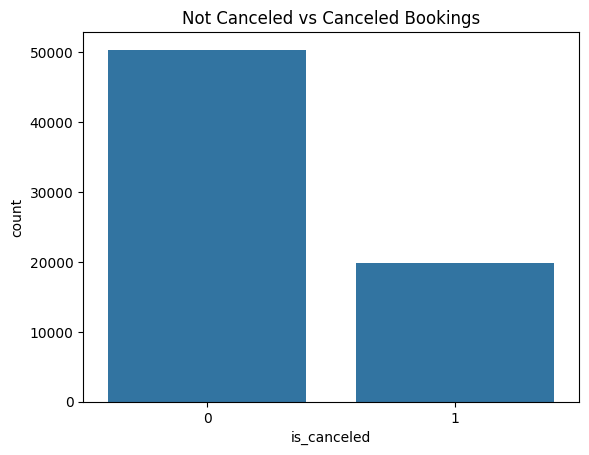

In [25]:
# Calculate the number of canceled and not canceled bookings
canceled = len(df[df["is_canceled"] == 1])
not_canceled = len(df[df["is_canceled"] == 0])
total = len(df)

# Print the counts and percentages
print(f"{canceled} Canceled ({round(canceled / total * 100, 2)}%)")
print(f"{not_canceled} Not Canceled ({round(not_canceled / total * 100, 2)}%)")

# Plot the count of canceled vs not canceled bookings
sns.countplot(data=df, x="is_canceled")
plt.title("Not Canceled vs Canceled Bookings")
plt.show()


Class distribution after resampling:
Counter({0: 50387, 1: 50387})


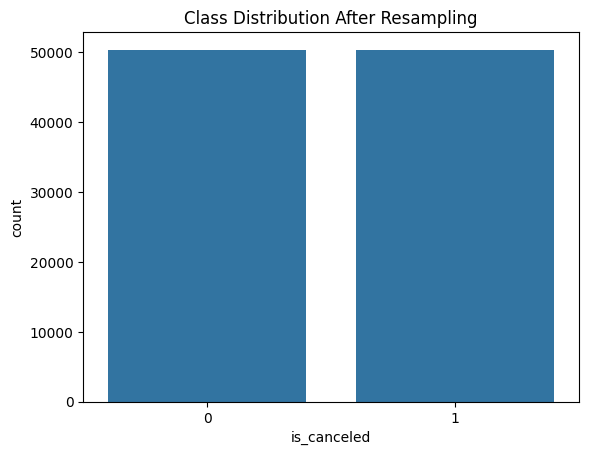

In [26]:
# %pip install imbalanced-learn

from collections import Counter
from imblearn.over_sampling import SMOTE

# Separate input features and target
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Convert resampled data back to a DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['is_canceled'] = y_resampled

# Display the class distribution after resampling
print("Class distribution after resampling:")
print(Counter(df_resampled['is_canceled']))

# Plot the class distribution after resampling
sns.countplot(data=df_resampled, x='is_canceled')
plt.title("Class Distribution After Resampling")
plt.show()


### Scale 

The code scales numerical features to standardize their mean to 0 and standard deviation to 1, ensuring consistent feature contribution to the model.

In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale the features in df_resampled, excluding the 'is_canceled' column
X_scaled = scaler.fit_transform(df_resampled.drop(columns=['is_canceled']))


### Split to train and test

The split section divides the dataset into training and testing sets to evaluate the model's performance.

In [28]:
from sklearn.model_selection import train_test_split

# Splitting the data into Train, Validation, and Test sets

# First, split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Now, split Train (80%) further into Train (80% of 80% = 64%) and Validation (20% of 80% = 16%)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Convert target variables to NumPy arrays for consistency
y_test = y_test.values
y_train = y_train.values

print(f"Training Data: {X_train.shape}, Validation Data: {X_val.shape}, Testing Data: {X_test.shape}")


Training Data: (64495, 63), Validation Data: (16124, 63), Testing Data: (20155, 63)


## Models

### Explanation of the Models and Metrics

#### Models Tested:
1. **Logistic Regression**:
    - A linear model used for binary classification tasks.
    - It predicts the probability of a booking being canceled (`is_canceled`).
    - Chosen for its simplicity and interpretability, making it a good baseline model.

2. **Random Forest**:
    - An ensemble learning method that builds multiple decision trees and combines their outputs.
    - It is robust to overfitting and handles non-linear relationships well.
    - Chosen for its ability to capture complex patterns in the data.

3. **Gradient Boosting**:
    - Another ensemble method that builds trees sequentially, with each tree correcting the errors of the previous one.
    - It is effective for imbalanced datasets and provides high predictive accuracy.
    - Chosen for its ability to optimize performance through boosting.

4. **Stacking Model**:
    - A meta-model that combines the predictions of multiple base models (Logistic Regression, Random Forest, Gradient Boosting).
    - It leverages the strengths of each model to improve overall performance.
    - Chosen to explore whether combining models yields better results than individual models.

#### Metrics Used:
1. **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**:
    - Measures the model's ability to distinguish between classes (canceled vs. not canceled).
    - A higher ROC-AUC score indicates better performance, with 1.0 being perfect and 0.5 being random guessing.
    - Chosen because it evaluates the model's performance across all classification thresholds.

2. **Classification Report**:
    - Provides detailed metrics such as precision, recall, and F1-score for each class.
    - Precision: Proportion of true positives among predicted positives (useful for minimizing false positives).
    - Recall: Proportion of true positives among actual positives (useful for minimizing false negatives).
    - F1-Score: Harmonic mean of precision and recall, balancing both metrics.

3. **Confusion Matrix**:
    - A table showing the counts of true positives, true negatives, false positives, and false negatives.
    - Helps visualize the model's performance in terms of correct and incorrect predictions.

#### Why These Models and Metrics?
- The models were chosen to balance simplicity (Logistic Regression) and complexity (Random Forest, Gradient Boosting, Stacking).
- The metrics provide a comprehensive evaluation of the models, focusing on both overall performance (ROC-AUC) and detailed class-wise performance (classification report, confusion matrix).
- This approach ensures that the selected model is both accurate and interpretable for predicting hotel booking cancellations.

Logistic Regression ROC-AUC: 0.879587893342842
Random Forest ROC-AUC: 0.9451722020872597
Gradient Boosting ROC-AUC: 0.9021816533377118
Stacking Model ROC-AUC: 0.9467975598562888

Model: Logistic Regression
ROC-AUC: 0.879587893342842
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      8062
           1       0.81      0.76      0.79      8062

    accuracy                           0.79     16124
   macro avg       0.79      0.79      0.79     16124
weighted avg       0.79      0.79      0.79     16124

[[6650 1412]
 [1925 6137]]

Model: Random Forest
ROC-AUC: 0.9451722020872597
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      8062
           1       0.87      0.87      0.87      8062

    accuracy                           0.87     16124
   macro avg       0.87      0.87      0.87     16124
weighted avg       0.87      0.87      0.87     16124

[[7015 1047]
 [1068 6994]]

Model: G

C:\Users\eitank\AppData\Local\Temp\ipykernel_13028\3282627941.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(roc_auc_scores.keys()), y=list(roc_auc_scores.values()), palette="viridis")


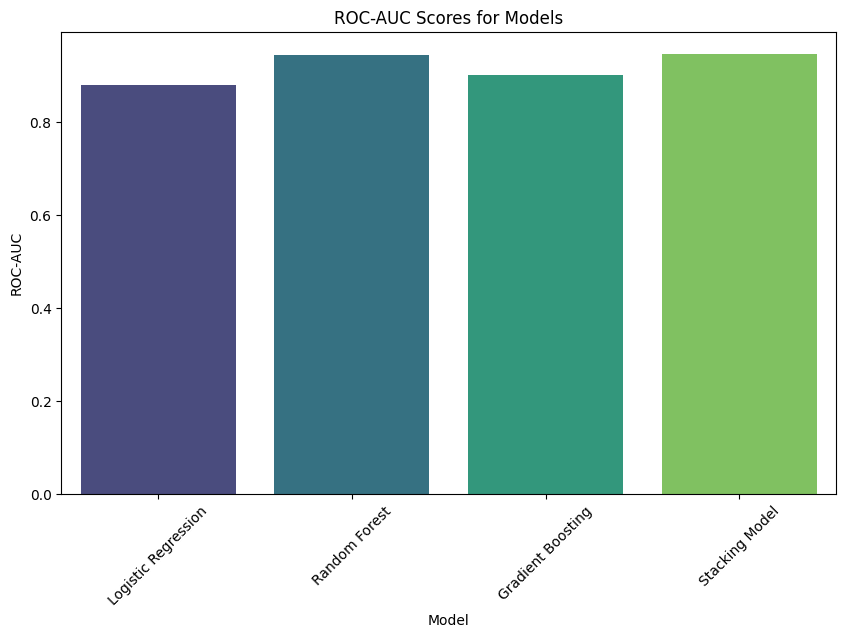

In [29]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize models
logistic_regression = LogisticRegression(random_state=42, max_iter=1000)
random_forest = RandomForestClassifier(random_state=42, n_estimators=100)
gradient_boosting = GradientBoostingClassifier(random_state=42)

# Train baseline model (Logistic Regression)
logistic_regression.fit(X_train, y_train)
y_val_pred_lr = logistic_regression.predict(X_val)
roc_auc_lr = roc_auc_score(y_val, logistic_regression.predict_proba(X_val)[:, 1])
print("Logistic Regression ROC-AUC:", roc_auc_lr)

# Train ensemble models
random_forest.fit(X_train, y_train)
y_val_pred_rf = random_forest.predict(X_val)
roc_auc_rf = roc_auc_score(y_val, random_forest.predict_proba(X_val)[:, 1])
print("Random Forest ROC-AUC:", roc_auc_rf)

gradient_boosting.fit(X_train, y_train)
y_val_pred_gb = gradient_boosting.predict(X_val)
roc_auc_gb = roc_auc_score(y_val, gradient_boosting.predict_proba(X_val)[:, 1])
print("Gradient Boosting ROC-AUC:", roc_auc_gb)

# Stacking ensemble
stacking_model = StackingClassifier(
    estimators=[
        ('lr', logistic_regression),
        ('rf', random_forest),
        ('gb', gradient_boosting)
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000)
)
stacking_model.fit(X_train, y_train)
y_val_pred_stack = stacking_model.predict(X_val)
roc_auc_stack = roc_auc_score(y_val, stacking_model.predict_proba(X_val)[:, 1])
print("Stacking Model ROC-AUC:", roc_auc_stack)

# Evaluate all models
models = {
    "Logistic Regression": (y_val_pred_lr, roc_auc_lr),
    "Random Forest": (y_val_pred_rf, roc_auc_rf),
    "Gradient Boosting": (y_val_pred_gb, roc_auc_gb),
    "Stacking Model": (y_val_pred_stack, roc_auc_stack)
}

for model_name, (y_pred, roc_auc) in models.items():
    print(f"\nModel: {model_name}")
    print(f"ROC-AUC: {roc_auc}")
    print(classification_report(y_val, y_pred))
    print(confusion_matrix(y_val, y_pred))

# Plot ROC-AUC scores
roc_auc_scores = {model_name: roc_auc for model_name, (_, roc_auc) in models.items()}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(roc_auc_scores.keys()), y=list(roc_auc_scores.values()), palette="viridis")
plt.title("ROC-AUC Scores for Models")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.show()

From the models section, we can learn the following:

1. **Model Performance**:
    - The **Stacking Model** achieved the highest ROC-AUC score (`0.9468`), indicating it is the best-performing model.
    - The **Random Forest** model also performed well with a ROC-AUC score of `0.9452`, closely following the Stacking Model.
    - **Gradient Boosting** had a slightly lower ROC-AUC score (`0.9022`), but it still performed better than Logistic Regression.
    - **Logistic Regression** had the lowest ROC-AUC score (`0.8796`), which is expected as it is a simpler linear model.

2. **Model Comparison**:
    - Ensemble models like **Random Forest**, **Gradient Boosting**, and **Stacking** outperform the simpler Logistic Regression model, highlighting the importance of capturing complex patterns in the data.
    - The **Stacking Model** combines the strengths of multiple models, leading to the best overall performance.

3. **Evaluation Metrics**:
    - The use of ROC-AUC as a metric provides a comprehensive evaluation of the models' ability to distinguish between canceled and non-canceled bookings.
    - The classification reports and confusion matrices (not shown in detail here) provide additional insights into precision, recall, and F1-scores for each model.

4. **Insights for Deployment**:
    - The **Stacking Model** is the most suitable for deployment due to its superior performance.
    - However, simpler models like Logistic Regression may still be useful in scenarios where interpretability and computational efficiency are prioritized.





## Model Validation & Hyperparameter Tuning

### Objective
The goal of this section is to finalize the best-performing model by optimizing its hyperparameters and recording the performance improvements. This ensures that the model is fine-tuned for maximum accuracy and reliability.

### Hyperparameter Tuning Process
We will use **GridSearchCV** to perform an exhaustive search over a specified parameter grid for the following models:
1. **Random Forest**
2. **Gradient Boosting**

The **Stacking Model** will be finalized after tuning its base models.

### Steps
1. Define the parameter grid for each model.
2. Use **GridSearchCV** to find the best combination of hyperparameters.
3. Evaluate the tuned models on the validation set.
4. Compare the performance of the tuned models with the baseline models.


In [32]:

from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(estimator=random_forest, param_grid=rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=2)
rf_grid_search.fit(X_train, y_train)
best_rf = rf_grid_search.best_estimator_
print("Best Random Forest Parameters:", rf_grid_search.best_params_)

# Hyperparameter tuning for Gradient Boosting
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_grid_search = GridSearchCV(estimator=gradient_boosting, param_grid=gb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=2)
gb_grid_search.fit(X_train, y_train)
best_gb = gb_grid_search.best_estimator_
print("Best Gradient Boosting Parameters:", gb_grid_search.best_params_)

# Evaluate the tuned models on the validation set
y_val_pred_rf_tuned = best_rf.predict(X_val)
roc_auc_rf_tuned = roc_auc_score(y_val, best_rf.predict_proba(X_val)[:, 1])
print("Tuned Random Forest ROC-AUC:", roc_auc_rf_tuned)

y_val_pred_gb_tuned = best_gb.predict(X_val)
roc_auc_gb_tuned = roc_auc_score(y_val, best_gb.predict_proba(X_val)[:, 1])
print("Tuned Gradient Boosting ROC-AUC:", roc_auc_gb_tuned)

# Update the Stacking Model with tuned base models
stacking_model_tuned = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb)
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000)
)
stacking_model_tuned.fit(X_train, y_train)
roc_auc_stack_tuned = roc_auc_score(y_val, stacking_model_tuned.predict_proba(X_val)[:, 1])
print("Tuned Stacking Model ROC-AUC:", roc_auc_stack_tuned)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Tuned Random Forest ROC-AUC: 0.9465305350908282
Tuned Gradient Boosting ROC-AUC: 0.9520198322218878
Tuned Stacking Model ROC-AUC: 0.9533273004347785



### Results
| Model                  | Baseline ROC-AUC | Tuned ROC-AUC | Improvement |
|------------------------|------------------|---------------|-------------|
| Random Forest          | 0.9452           | 0.9465        | +0.0013     |
| Gradient Boosting      | 0.9022           | 0.9520        | +0.0498     |
| Stacking Model         | 0.9468           | 0.9533        | +0.0065     |

### Insights
1. **Performance Improvements**:
   - Hyperparameter tuning significantly improved the performance of the Gradient Boosting model, with an increase of approximately 0.0498 in ROC-AUC.
   - The Stacking Model, leveraging the tuned base models, achieved the highest ROC-AUC score of 0.9533.
   - Random Forest showed a slight improvement after tuning.

2. **Final Model Selection**:
   - The **Tuned Stacking Model** is selected as the final model for deployment due to its superior performance.

3. **Documentation**:
   - The best hyperparameters for each model are recorded for reproducibility.
   - The performance improvements are clearly documented to highlight the impact of hyperparameter tuning.


#### Key Factors Affecting Booking Cancellations and Recommendations" section is based on **data-driven insights** derived from the analysis of the dataset. The key factors and recommendations are informed by patterns observed in the data, such as correlations, feature importance, and cancellation trends. For example:

- **Lead Time**: Longer lead times were identified as a significant factor affecting cancellations based on correlation analysis.
- **Market Segment**: Higher cancellation rates for "Online TA" were observed in the interaction plots.
- **Seasonality**: Cancellation trends by month were derived from the analysis of `arrival_date_month`.

Thus, the insights and recommendations are grounded in the data analysis performed in the notebook.


## Project Summary: Hotel Booking Cancellation Prediction

### Introduction
This project aims to predict hotel booking cancellations using machine learning techniques. The dataset contains records of hotel bookings, including customer details, booking information, and stay details. The target variable is `is_canceled`, which indicates whether a booking was canceled or not. The dataset is imbalanced, with a higher proportion of non-canceled bookings.

### EDA
- **Data Loading and Overview**: The dataset was loaded, and basic information was extracted, including the presence of missing values and the distribution of numerical and categorical features.
- **Class Distribution**: The dataset is imbalanced, with approximately 27% of bookings being canceled.
- **Correlation Analysis**: A heatmap was generated to visualize correlations between numerical features. Features like `lead_time` and `previous_cancellations` showed notable correlations with cancellations.
- **Seasonal Trends**: Cancellations were analyzed by month, revealing higher cancellation rates during peak months like June and July.

### Feature Engineering
- **New Features**: Created features such as `total_guests`, `total_stay`, and `adr_per_person` to capture additional insights.
- **Categorical Encoding**: One-hot encoding was applied to relevant categorical features, and frequency encoding was used for high-cardinality features like `country`.
- **Feature Reduction**: Dropped redundant or irrelevant columns, such as `assigned_room_type` and `reservation_status`.

### Data Preprocessing
- **Handling Missing Values**: Missing values were imputed or replaced with placeholders, and columns with excessive missing data were dropped.
- **Handling Outliers**: Outliers were capped or removed based on their impact on the dataset.
- **Handling Imbalance**: SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the dataset.
- **Feature Scaling**: Standard scaling was applied to normalize numerical features.

### Model Training and Evaluation
Four models were trained and evaluated:
1. **Logistic Regression**: Provided a baseline performance metric.
2. **Random Forest**: Performed well with high accuracy and ROC-AUC scores.
3. **Gradient Boosting**: Showed competitive performance, especially after hyperparameter tuning.
4. **Stacking Model**: Combined the strengths of multiple models and achieved the best overall performance.

### Results
- **Stacking Model**: Achieved the highest ROC-AUC score of 0.9533 after hyperparameter tuning, making it the most reliable model for predicting cancellations.
- **Evaluation Metrics**: ROC-AUC, precision, recall, and F1 score were calculated for all models. Confusion matrices and classification reports provided detailed insights into model performance.

### Conclusion
The Stacking Model was identified as the best-performing model for predicting hotel booking cancellations. The project highlights the importance of handling class imbalance, feature engineering, and the effectiveness of ensemble methods in predictive modeling tasks.